In [3]:
import requests
import pandas as pd
from typing import Optional, Dict, Any, List

BASE_TEAMS = "https://api.nhle.com/stats/rest/en/team"

def safe_get_json(url: str) -> Optional[Dict[str, Any]]:
    """GET JSON safely; return None if not JSON/200."""
    resp = requests.get(url)
    ctype = resp.headers.get("Content-Type", "")
    if resp.status_code == 200 and "application/json" in ctype:
        try:
            return resp.json()
        except Exception:
            return None
    return None

def parse_height(height_str: Optional[str]) -> Optional[int]:
    """Convert height like 6'1\" to inches; handle None or unexpected formats."""
    if not height_str:
        return None
    s = height_str.strip()
    # Normalize any quotes variations
    s = s.replace("’", "'").replace("″", '"').replace("”", '"').replace("“", '"')
    try:
        if "'" in s:
            feet, inches_part = s.split("'", 1)
            inches_part = inches_part.replace('"', '').strip()
            return int(feet) * 12 + int(inches_part)
        # Fallback: pure inches like "73"
        if s.isdigit():
            return int(s)
    except Exception:
        pass
    return None

def extract_name(player: Dict[str, Any]) -> str:
    """Handle both nested and flat name fields."""
    fn = player.get("firstName")
    ln = player.get("lastName")
    if isinstance(fn, dict):
        fn = fn.get("default", "")
    if isinstance(ln, dict):
        ln = ln.get("default", "")
    # Some payloads use 'firstName'/'lastName' as strings or 'firstName'/'lastName' keys only.
    fn = fn or player.get("first_name", "") or player.get("first", "") or ""
    ln = ln or player.get("last_name", "") or player.get("last", "") or ""
    name = f"{fn} {ln}".strip()
    return name

def extract_height(player: Dict[str, Any]) -> Optional[int]:
    """Try common height fields."""
    for key in ("height", "playerHeight", "heightInInches"):
        val = player.get(key)
        if isinstance(val, (int, float)):
            return int(val)
        if isinstance(val, str):
            h = parse_height(val)
            if h is not None:
                return h
    return None

def extract_weight(player: Dict[str, Any]) -> Optional[int]:
    """Try common weight fields."""
    for key in ("weight", "playerWeight", "weightInPounds"):
        val = player.get(key)
        if isinstance(val, (int, float)):
            return int(val)
        if isinstance(val, str) and val.isdigit():
            return int(val)
    return None

def get_active_teams() -> List[Dict[str, Any]]:
    """Fetch all teams; return list of dicts with id, name, triCode."""
    data = safe_get_json(BASE_TEAMS)
    if not data or "data" not in data:
        return []
    teams = []
    for t in data["data"]:
        teams.append({
            "id": t.get("id"),
            "name": t.get("fullName") or t.get("teamName") or t.get("name") or "",
            "triCode": t.get("triCode") or t.get("rawTricode") or ""
        })
    return teams

def try_roster(team_id: int, tri: str, season: str) -> Optional[Dict[str, Any]]:
    """Try multiple roster endpoints; return first valid JSON payload."""
    candidates = [
        # Newer API patterns (team triCode and id)
        f"https://api-web.nhle.com/v1/roster/{tri}/{season}",
        f"https://api-web.nhle.com/v1/roster/{team_id}/{season}",
        # Legacy stats REST (may be disabled but we try)
        f"https://api.nhle.com/stats/rest/en/roster?teamId={team_id}&season={season}",
    ]
    for url in candidates:
        data = safe_get_json(url)
        if not data:
            continue
        # Accept if it looks like a roster
        if any(k in data for k in ("forwards", "defensemen", "goalies")):
            return data
        # Some variants return a flat list under "data"
        if isinstance(data, dict) and "data" in data and isinstance(data["data"], list):
            return data
    return None

def collect_players(season="20232024") -> List[Dict[str, Any]]:
    """Collect players with height/weight; skip teams that don't return JSON rosters."""
    teams = get_active_teams()
    players: List[Dict[str, Any]] = []
    for t in teams:
        tid, tri, tname = t["id"], t["triCode"], t["name"]
        if not tid or not tri:
            continue
        roster = try_roster(tid, tri, season)
        if not roster:
            continue
        # Normalize different shapes
        if "data" in roster and isinstance(roster["data"], list):
            roster_players = roster["data"]
        else:
            roster_players = roster.get("forwards", []) + roster.get("defensemen", []) + roster.get("goalies", [])
        if not roster_players:
            continue

        for p in roster_players:
            h_in = extract_height(p)
            w_lb = extract_weight(p)
            name = extract_name(p)
            if not name:
                # fallback: some payloads store 'playerName'
                name = p.get("playerName", "") or p.get("name", "")
            players.append({
                "name": name,
                "team": tname,
                "team_abbrev": tri,
                "height_in_inches": h_in,
                "weight_in_pounds": w_lb,
                "height_cm": h_in * 2.54 if h_in else None,
                "weight_kg": w_lb * 0.453592 if w_lb else None,
            })
    return players

# Run it
all_players = collect_players(season="20232024")
nhl_df = pd.DataFrame(all_players)
print(f"Players collected: {len(all_players)}")
print(nhl_df.shape)
nhl_df.head()


Players collected: 653
(653, 7)


,name,team,team_abbrev,height_in_inches,weight_in_pounds,height_cm,weight_kg
0,Josh Anderson,Montréal Canadiens,MTL,75,224,190.50,101.604608
1,Joel Armia,Montréal Canadiens,MTL,75,216,190.50,97.975872
2,Cole Caufield,Montréal Canadiens,MTL,68,175,172.72,79.378600
3,Kirby Dach,Montréal Canadiens,MTL,76,217,193.04,98.429464
4,Christian Dvorak,Montréal Canadiens,MTL,73,192,185.42,87.089664


In [7]:


import pandas as pd
from io import StringIO

data = """Player	Team	Age	Height	Weight	COLLEGE	COUNTRY	DRAFT YEAR	DRAFT ROUND	DRAFT NUMBER	GP	PTS	REB	AST	NETRTG	OREB%	DREB%	USG%	TS%	AST%
A.J. Lawson	DAL	23	6-6	179	South Carolina	Canada	Undrafted	Undrafted	Undrafted	42.0	3.2	1.2	0.5	1.2	3.9	10.5	18.0	51.9	8.9
AJ Green	MIL	24	6-4	190	Northern Iowa	USA	Undrafted	Undrafted	Undrafted	56.0	4.5	1.1	0.5	3.5	1.5	8.9	15.0	61.7	6.8
AJ Griffin	ATL	20	6-6	220	Duke	USA	2022	1	16	20.0	2.4	0.9	0.3	-14.0	1.1	10.8	16.7	38.2	4.1
Aaron Gordon	DEN	28	6-8	235	Arizona	USA	2014	1	4	73.0	13.9	6.5	3.5	8.7	7.8	12.9	17.4	60.7	14.7
Aaron Holiday	HOU	27	6-0	185	UCLA	USA	2018	1	23	78.0	6.6	1.6	1.8	2.9	1.7	7.5	15.8	57.8	15.7
Aaron Nesmith	IND	24	6-6	215	Vanderbilt	USA	2020	1	14	72.0	12.2	3.8	1.5	4.3	3.2	10.3	15.8	63.1	6.7
Aaron Wiggins	OKC	25	6-5	190	Maryland	USA	2021	2	55	78.0	6.9	2.4	1.1	5.7	5.2	9.5	16.3	66.4	9.6
Adam Flagler	OKC	24	6-3	180	Baylor	USA	Undrafted	Undrafted	Undrafted	2.0	1.5	0.0	2.0	0.0	0.0	0.0	21.2	21.4	36.4
Adama Sanogo	CHI	22	6-9	245	UCONN	Mali	Undrafted	Undrafted	Undrafted	9.0	4.0	4.0	0.0	21.7	25.3	26.6	21.0	55.8	0.0
Admiral Schofield	ORL	27	6-5	241	Tennessee	United Kingdom	2019	2	42	23.0	1.1	0.7	0.3	-5.2	3.5	14.9	16.7	48.4	16.3
Al Horford	BOS	38	6-9	240	Florida	Dominican Republic	2007	1	3	65.0	8.6	6.4	2.6	11.4	4.8	17.8	11.9	65.0	12.4
Alec Burks	NYK	32	6-5	214	Colorado	USA	2011	1	12	66.0	10.4	2.3	1.3	-10.7	1.9	10.3	23.4	53.6	11.5
Aleksej Pokusevski	CHA	22	7-0	210	None	Serbia	2020	1	17	28.0	5.2	3.2	1.3	-9.7	4.2	17.3	17.2	52.5	13.2
Alex Caruso	CHI	30	6-5	186	Texas A&M	USA	Undrafted	Undrafted	Undrafted	71.0	10.1	3.8	3.5	0.3	3.1	10.3	14.6	61.3	16.7
Alex Fudge	DAL	21	6-8	200	Florida	USA	Undrafted	Undrafted	Undrafted	6.0	2.5	0.8	0.0	-47.3	8.7	2.9	17.6	47.2	0.0
Alex Len	SAC	31	7-0	250	Maryland	Ukraine	2013	1	5	48.0	2.5	2.7	1.0	15.4	9.8	17.9	11.4	62.5	14.2
Alondes Williams	MIA	25	6-4	210	Wake Forest	USA	Undrafted	Undrafted	Undrafted	7.0	0.7	0.1	0.0	-52.6	0.0	6.7	25.0	29.6	0.0
Alperen Sengun	HOU	21	6-11	243	None	Turkey	2021	1	16	63.0	21.1	9.3	5.0	0.8	8.6	19.3	27.0	58.5	24.8
Amari Bailey	CHA	20	6-3	185	UCLA	USA	2023	2	41	10.0	2.3	0.9	0.7	5.4	9.8	4.1	20.7	42.5	15.2
Amen Thompson	HOU	21	6-7	200	None	USA	2023	1	4	62.0	9.5	6.6	2.6	2.1	9.5	18.4	17.3	57.6	16.5
Amir Coffey	LAC	27	6-7	210	Minnesota	USA	Undrafted	Undrafted	Undrafted	70.0	6.6	2.1	1.1	-3.4	2.0	8.0	11.9	60.4	6.8
Andre Drummond	CHI	30	6-11	279	Connecticut	USA	2012	1	9	79.0	8.4	9.0	0.5	0.8	18.7	33.1	20.1	57.6	4.1
Andre Jackson Jr.	MIL	22	6-6	209	Connecticut	USA	2023	2	36	57.0	2.2	2.0	0.9	-7.3	7.7	12.7	9.7	59.6	11.3
Andrew Funk	CHI	24	6-5	200	Penn State	USA	Undrafted	Undrafted	Undrafted	5.0	0.0	0.0	0.0	17.0	0.0	0.0	10.8	0.0	0.0
Andrew Nembhard	IND	24	6-4	191	Gonzaga	Canada	2022	2	31	68.0	9.2	2.1	4.1	2.2	2.1	6.0	16.1	57.3	20.8
Andrew Wiggins	GSW	29	6-7	197	Kansas	Canada	2014	1	1	71.0	13.2	4.5	1.7	-1.3	5.5	10.5	20.6	54.4	8.7
Anfernee Simons	POR	25	6-3	193	None	USA	2018	1	24	46.0	22.6	3.6	5.5	-10.6	1.3	9.7	27.6	56.8	26.8
Anthony Black	ORL	20	6-7	200	Arkansas	USA	2023	1	6	69.0	4.6	2.0	1.3	-1.0	2.9	9.3	12.3	56.0	10.8
Anthony Davis	LAL	31	6-10	253	Kentucky	USA	2012	1	1	76.0	24.7	12.6	3.5	2.6	9.3	25.2	26.1	62.1	15.1
Anthony Edwards	MIN	22	6-4	225	Georgia	USA	2020	1	1	79.0	25.9	5.4	5.1	7.3	2.0	13.1	31.4	57.5	24.1
Anthony Gill	WAS	31	6-8	230	Virginia	USA	Undrafted	Undrafted	Undrafted	50.0	3.8	1.9	0.7	1.2	7.8	11.7	17.7	53.7	9.8
Armoni Brooks	BKN	26	6-3	195	Houston	USA	2019			10.0	4.2	1.8	0.5	13.7	6.1	9.8	18.8	44.8	6.0
Ashton Hagans	POR	24	6-3	190	Kentucky	USA	Undrafted	Undrafted	Undrafted	19.0	4.2	2.4	2.8	-1.1	4.1	10.1	14.4	51.0	24.4
Ausar Thompson	DET	21	6-6	205	None	USA	2023	1	5	63.0	8.8	6.4	1.9	-5.3	7.7	17.3	16.1	52.2	10.8
Austin Reaves	LAL	26	6-5	197	Oklahoma	USA	Undrafted	Undrafted	Undrafted	82.0	15.9	4.3	5.5	-1.0	2.3	10.7	19.8	61.3	23.7
Ayo Dosunmu	CHI	24	6-5	200	Illinois	USA	2021	2	38	76.0	12.2	2.8	3.2	-3.3	2.4	7.2	16.8	60.4	15.7
Bam Adebayo	MIA	26	6-9	255	Kentucky	USA	2017	1	14	71.0	19.3	10.4	3.9	0.8	6.7	24.2	24.7	57.6	19.3
Ben Sheppard	IND	22	6-6	190	Belmont	USA	2023	1	26	57.0	4.4	1.6	0.9	4.7	1.8	9.2	12.5	52.4	7.2
Ben Simmons	BKN	27	6-10	240	Louisiana State	Australia	2016	1	1	15.0	6.1	7.9	5.7	-3.4	8.0	24.1	12.6	57.1	30.6
Bennedict Mathurin	IND	22	6-5	210	Arizona	Canada	2022	1	6	59.0	14.5	4.0	2.0	-2.9	3.8	11.3	22.6	56.2	10.5
Bilal Coulibaly	WAS	19	6-8	195	None	France	2023	1	7	63.0	8.4	4.1	1.7	-11.0	3.1	11.6	13.9	54.3	8.6
Bismack Biyombo	OKC	31	6-8	255	None	DRC	2011	1	7	40.0	4.4	5.2	1.3	-3.8	7.6	17.9	10.6	56.2	8.7
Blake Wesley	SAS	21	6-3	185	Notre Dame	USA	2022	1	25	61.0	4.4	1.5	2.7	-7.8	1.9	8.4	14.4	53.7	25.7
Boban Marjanovic	HOU	35	7-4	290	None	Serbia	Undrafted	Undrafted	Undrafted	14.0	3.2	2.3	0.4	-13.4	10.0	30.9	24.7	56.0	12.0
Bobby Portis	MIL	29	6-10	250	Arkansas	USA	2015	1	22	82.0	13.8	7.4	1.3	-0.1	7.1	22.8	22.4	58.1	7.8
Bogdan Bogdanović	ATL	31	6-5	225	None	Serbia	2014	1	27	79.0	16.9	3.4	3.1	1.9	2.1	9.2	21.8	56.9	14.7
Bojan Bogdanovic	NYK	35	6-7	226	None	Croatia	2011	2	31	57.0	15.2	2.7	1.7	-11.4	1.5	9.2	24.2	58.1	10.2
Bol Bol	PHX	24	7-3	220	Oregon	Sudan	2019	2	44	43.0	5.2	3.2	0.4	0.1	6.9	20.2	15.6	70.0	5.4
Bones Hyland	LAC	23	6-2	169	Va Commonwealth	USA	2021	1	26	37.0	6.9	1.5	2.5	-6.0	0.9	8.8	24.1	49.0	26.9
Bradley Beal	PHX	31	6-4	207	Florida	USA	2012	1	3	53.0	18.2	4.4	5.0	3.0	3.3	9.9	22.4	60.7	21.5
Brandin Podziemski	GSW	21	6-4	205	Santa Clara	USA	2023	1	19	74.0	9.2	5.8	3.7	5.9	5.8	14.9	14.9	54.0	17.6
Brandon Boston	LAC	22	6-6	188	Kentucky	USA	2021	2	51	32.0	5.2	1.6	0.4	-15.7	5.0	9.3	24.0	47.6	6.0
Brandon Clarke	MEM	27	6-8	215	Gonzaga	Canada	2019	1	21	6.0	11.3	5.3	1.5	-3.9	7.7	14.5	18.8	54.8	11.1
Brandon Ingram	NOP	26	6-8	190	Duke	USA	2016	1	2	64.0	20.8	5.1	5.7	4.0	2.1	13.3	26.9	57.8	25.9
Brandon Miller	CHA	21	6-7	200	Alabama	USA	2023	1	2	74.0	17.3	4.3	2.4	-10.2	2.5	11.2	23.5	55.2	11.4
Brandon Williams	DAL	24	6-1	190	Arizona	USA	Undrafted	Undrafted	Undrafted	17.0	3.2	0.8	1.0	-21.7	2.8	7.6	23.9	43.9	25.8
Braxton Key	DEN	27	6-8	225	Virginia	USA	Undrafted	Undrafted	Undrafted	20.0	1.1	0.9	0.5	-8.3	4.9	24.2	14.8	53.6	23.1
Brice Sensabaugh	UTA	20	6-5	235	Ohio State	USA	2023	1	28	32.0	7.5	3.2	1.7	-14.2	2.7	15.1	20.1	51.1	13.4
Brook Lopez	MIL	36	7-1	282	Stanford	USA	2008	1	10	79.0	12.5	5.2	1.6	5.2	4.9	11.0	15.6	60.8	7.1
Bruce Brown	TOR	27	6-4	202	Miami	USA	2018	2	42	67.0	10.8	4.2	2.9	-5.8	2.8	12.6	16.1	56.3	13.2
Bruno Fernando	ATL	25	6-9	240	Maryland	Angola	2019	2	34	45.0	6.3	4.3	1.0	-6.4	8.8	20.1	17.2	61.5	10.0
Bryce McGowens	CHA	21	6-6	175	Nebraska	USA	2022	2	40	59.0	5.1	1.7	0.9	-13.0	1.9	9.8	14.7	56.5	8.6
Buddy Boeheim	DET	24	6-5	205	Syracuse	USA	Undrafted	Undrafted	Undrafted	10.0	3.4	1.0	0.3	10.2	3.4	7.3	16.1	50.9	5.4
Buddy Hield	PHI	31	6-4	220	Oklahoma	Bahamas	2016	1	6	84.0	12.1	3.2	2.8	1.1	2.7	9.8	18.6	57.8	14.3
CJ McCollum	NOP	32	6-3	190	Lehigh	USA	2013	1	10	66.0	20.0	4.3	4.6	3.7	1.8	11.6	24.4	59.2	20.9
Cade Cunningham	DET	22	6-6	220	Oklahoma State	USA	2021	1	1	62.0	22.7	4.3	7.5	-7.9	1.6	11.5	29.8	54.6	35.9
Caleb Houstan	ORL	21	6-8	205	Michigan	Canada	2022	2	32	59.0	4.3	1.4	0.5	-1.8	3.4	6.7	12.2	58.2	5.1
Caleb Martin	MIA	28	6-5	205	Nevada	USA	Undrafted	Undrafted	Undrafted	64.0	10.0	4.4	2.2	1.9	4.2	11.9	16.8	53.1	11.8
Cam Reddish	LAL	24	6-7	217	Duke	USA	2019	1	10	48.0	5.4	2.1	1.0	-2.8	2.8	7.1	12.3	50.4	6.2
Cam Thomas	BKN	22	6-3	210	Louisiana State	Japan	2021	1	27	66.0	22.5	3.2	2.9	-5.2	1.3	8.9	29.6	55.4	15.1
Cam Whitmore	HOU	19	6-7	230	Villanova	USA	2023	1	20	47.0	12.3	3.8	0.7	-1.0	4.4	14.8	25.5	56.1	5.8
Cameron Johnson	BKN	28	6-8	210	North Carolina	USA	2019	1	11	58.0	13.4	4.3	2.4	-3.4	3.2	12.4	19.0	58.2	12.9
Cameron Payne	PHI	29	6-3	183	Murray State	USA	2015	1	14	78.0	7.4	1.5	2.6	-0.8	1.6	7.3	18.5	56.6	22.2
Caris LeVert	CLE	29	6-6	205	Michigan	USA	2016	1	20	68.0	14.0	4.1	5.1	2.8	2.0	12.1	22.4	52.4	25.8
Cason Wallace	OKC	20	6-3	195	Kentucky	USA	2023	1	10	82.0	6.8	2.3	1.5	3.9	3.2	7.7	12.7	61.2	9.2
Cedi Osman	SAS	29	6-7	230	None	Turkey	2015	2	31	72.0	6.8	2.5	1.7	-13.2	1.8	12.2	14.6	60.1	13.1
Charles Bassey	SAS	23	6-10	230	Western Kentucky	Nigeria	2021	2	53	19.0	3.3	4.0	1.1	-11.6	10.2	26.5	11.0	73.9	13.6
Charlie Brown Jr.	NYK	27	6-6	199	St. Joseph's (PA)	USA	Undrafted	Undrafted	Undrafted	8.0	0.8	0.3	0.0	-1.0	2.5	2.7	14.5	30.0	0.0
Chet Holmgren	OKC	22	7-1	208	Gonzaga	USA	2022	1	2	82.0	16.5	7.9	2.4	9.0	5.6	19.8	21.0	63.2	11.2
Chimezie Metu	DET	27	6-10	225	USC	USA	2018	2	49	51.0	6.5	3.8	0.9	-6.6	5.0	17.7	16.2	61.0	8.0
Chris Boucher	TOR	31	6-9	200	Oregon	Saint Lucia	Undrafted	Undrafted	Undrafted	50.0	6.4	4.1	0.5	2.4	8.4	20.2	16.7	62.5	4.4
Chris Duarte	SAC	27	6-5	190	Oregon	Dominican Republic	2021	1	13	59.0	3.9	1.8	0.7	-3.1	3.4	11.3	14.6	51.2	8.2
Chris Livingston	MIL	20	6-6	220	Kentucky	USA	2023	2	58	21.0	1.2	1.0	0.2	-14.3	3.7	22.2	13.6	54.7	7.5
Chris Paul	GSW	39	6-0	175	Wake Forest	USA	2005	1	4	58.0	9.2	3.9	6.8	2.8	1.1	12.6	15.4	54.4	34.2
Christian Braun	DEN	23	6-6	220	Kansas	USA	2022	1	21	82.0	7.3	3.7	1.6	0.7	4.6	12.6	15.2	55.4	10.9
Christian Wood	LAL	28	6-8	214	UNLV	USA	Undrafted	Undrafted	Undrafted	50.0	6.9	5.1	1.0	0.0	4.8	22.6	17.3	56.8	7.9
Chuma Okeke	ORL	25	6-7	229	Auburn	USA	2019	1	16	47.0	2.3	1.7	0.4	-7.3	3.9	14.5	13.1	46.5	7.6
Clint Capela	ATL	30	6-10	256	None	Switzerland	2014	1	25	73.0	11.5	10.6	1.2	-0.1	15.7	23.2	16.7	59.0	6.7
Coby White	CHI	24	6-5	195	North Carolina	USA	2019	1	7	79.0	19.1	4.5	5.1	-0.7	1.5	11.0	22.4	57.0	20.4
Cody Martin	CHA	28	6-6	205	Nevada	USA	2019	2	36	28.0	7.5	3.9	3.7	-10.5	2.4	12.4	15.7	46.0	19.2
Cody Zeller	NOP	31	6-11	240	Indiana	USA	2013	1	4	43.0	1.8	2.6	0.9	6.3	13.3	18.5	11.6	48.3	14.9
Colby Jones	SAC	22	6-6	207	Xavier	USA	2023	2	34	30.0	2.1	1.3	0.7	1.5	7.6	12.0	17.8	42.2	15.9
Cole Anthony	ORL	24	6-2	185	North Carolina	USA	2020	1	15	81.0	11.6	3.8	2.9	2.6	3.6	14.0	23.2	54.5	20.0
Cole Swider	MIA	25	6-8	220	Syracuse	USA	Undrafted	Undrafted	Undrafted	18.0	2.3	0.4	0.3	-11.1	1.1	7.5	22.6	54.0	10.2
Colin Castleton	LAL	24	6-10	250	Florida	USA	Undrafted	Undrafted	Undrafted	16.0	1.5	0.8	0.2	-35.2	9.4	11.8	15.7	64.4	10.7
Collin Gillespie	DEN	25	6-1	195	Villanova	USA	Undrafted	Undrafted	Undrafted	24.0	3.6	0.9	1.1	2.5	0.4	8.5	16.6	58.6	16.4
Collin Sexton	UTA	25	6-3	190	Alabama	USA	2018	1	8	78.0	18.7	2.6	4.9	-3.4	3.3	6.4	26.7	60.7	28.3
Corey Kispert	WAS	25	6-6	224	Gonzaga	USA	2021	1	15	80.0	13.4	2.8	2.0	-10.7	1.4	9.1	19.1	62.0	11.1
Cory Joseph	GSW	32	6-2	200	Texas	Canada	2011	1	29	26.0	2.4	1.2	1.6	-3.0	1.9	8.3	10.8	47.0	17.4
Craig Porter Jr.	CLE	24	6-1	180	Wichita State	USA	Undrafted	Undrafted	Undrafted	51.0	5.6	2.1	2.3	-1.6	3.5	13.8	20.1	56.4	26.5
D'Angelo Russell	LAL	28	6-3	193	Ohio State	USA	2015	1	2	76.0	18.0	3.1	6.3	2.6	1.2	7.9	22.2	58.8	26.1
D'Moi Hodge	LAL	25	6-3	188	Missouri	British Virgin Islands	Undrafted	Undrafted	Undrafted	7.0	2.0	0.0	0.7	-44.2	0.0	0.0	17.2	44.1	22.7
D.J. Carton	TOR	23	6-3	200	Marquette	USA	Undrafted	Undrafted	Undrafted	4.0	2.8	1.0	0.8	-41.3	5.1	4.3	12.5	53.9	15.0
D.J. Wilson	PHI	28	6-10	231	Michigan	USA	2017	1	17	2.0	5.0	1.0	1.0	2.8	8.3	7.1	18.2	83.3	22.2
DaQuan Jeffries	NYK	26	6-5	222	Tulsa	USA	Undrafted	Undrafted	Undrafted	17.0	0.8	0.3	0.3	-7.4	0.0	9.6	19.3	39.1	18.5
Daishen Nix	MIN	22	6-3	226	None	USA	Undrafted	Undrafted	Undrafted	15.0	1.8	0.2	0.4	20.2	1.8	4.3	24.1	50.7	14.0
Dalano Banton	POR	24	6-8	204	Nebraska	Canada	2021	2	46	54.0	10.3	3.3	2.4	-10.2	3.6	13.0	25.0	50.4	20.0
Dalen Terry	CHI	21	6-7	195	Arizona	USA	2022	1	18	59.0	3.1	1.9	1.4	2.2	4.2	12.4	12.7	51.2	15.1
Damian Jones	CLE	29	6-10	245	Vanderbilt	USA	2016	1	30	39.0	2.7	1.6	0.4	-18.7	7.5	16.7	14.9	65.9	9.7
Damian Lillard	MIL	33	6-2	195	Weber State	USA	2012	1	6	73.0	24.3	4.4	7.0	6.9	1.4	10.2	27.4	59.0	28.4
Daniel Gafford	DAL	25	6-10	234	Arkansas	USA	2019	2	38	74.0	11.0	7.6	1.6	-2.2	10.5	18.6	14.5	73.1	8.3
Daniel Theis	LAC	32	6-8	245	None	Germany	Undrafted	Undrafted	Undrafted	60.0	6.3	4.1	1.0	2.4	8.4	15.0	15.0	59.7	8.1
Danilo Gallinari	MIL	35	6-10	236	None	Italy	2008	1	6	49.0	5.7	2.2	1.1	-8.4	3.2	14.6	17.1	60.1	12.7
Danny Green	PHI	37	6-6	215	North Carolina	USA	2009	2	46	2.0	0.0	1.0	0.5	-5.9	0.0	11.1	4.3	0.0	5.6
Danté Exum	DAL	28	6-5	214	None	Australia	2014	1	5	55.0	7.8	2.7	2.9	10.3	2.3	10.8	14.8	64.5	18.1
Danuel House Jr.	PHI	31	6-6	220	Texas A&M	USA	Undrafted	Undrafted	Undrafted	34.0	4.2	1.7	0.8	2.3	3.0	8.1	11.6	57.5	7.5
Dario Šarić	GSW	30	6-10	225	None	Croatia	2014	1	12	64.0	8.0	4.4	2.3	-1.6	6.3	19.2	19.0	60.0	18.7
Dariq Whitehead	BKN	19	6-6	220	Duke	USA	2023	1	22	2.0	1.5	2.0	1.5	-42.8	0.0	19.0	9.4	25.5	14.3
Darius Bazley	UTA	24	6-9	216	None	USA	2019	1	23	9.0	5.3	3.1	0.8	-11.3	5.1	13.2	11.8	68.0	6.2
Darius Garland	CLE	24	6-1	192	Vanderbilt	USA	2019	1	5	57.0	18.0	2.7	6.5	2.1	1.7	6.4	24.9	56.0	29.5
David Duke Jr.	SAS	24	6-4	204	Providence	USA	Undrafted	Undrafted	Undrafted	4.0	6.5	2.5	1.3	4.4	4.2	14.0	17.9	67.3	13.2
David Roddy	PHX	23	6-4	255	Colorado State	USA	2022	1	23	65.0	6.5	3.2	1.2	-9.3	4.2	13.4	17.7	48.4	10.2
Davion Mitchell	SAC	25	6-0	202	Baylor	USA	2021	1	9	72.0	5.3	1.3	1.9	-2.6	1.7	7.1	14.7	55.5	16.8
Davis Bertans	CHA	31	6-10	225	None	Latvia	2011	2	42	43.0	6.7	1.4	0.8	-7.2	1.3	8.1	16.9	58.3	7.6
Day'Ron Sharpe	BKN	22	6-9	265	North Carolina	USA	2021	1	29	61.0	6.8	6.4	1.4	4.8	16.3	23.5	18.5	59.6	13.7
De'Aaron Fox	SAC	26	6-3	185	Kentucky	USA	2017	1	5	74.0	26.6	4.6	5.6	4.3	2.4	10.4	30.0	56.7	24.4
De'Andre Hunter	ATL	26	6-8	221	Virginia	USA	2019	1	4	57.0	15.6	3.9	1.5	-1.3	1.8	11.6	20.4	59.5	7.3
De'Anthony Melton	PHI	26	6-3	200	USC	USA	2018	2	46	38.0	11.1	3.7	3.0	10.0	2.7	11.1	17.7	53.3	14.4
DeAndre Jordan	DEN	35	6-11	265	Texas A&M	USA	2008	2	35	36.0	3.9	4.4	0.7	-10.7	12.6	23.7	14.7	61.0	9.8
DeJon Jarreau	MEM	26	6-5	185	Houston	USA	Undrafted	Undrafted	Undrafted	9.0	4.8	4.9	2.9	-4.6	4.3	23.8	17.1	39.2	25.7
DeMar DeRozan	CHI	34	6-6	220	Southern California	USA	2009	1	9	79.0	24.0	4.3	5.3	-1.0	1.4	10.1	25.2	58.4	22.0
Dean Wade	CLE	27	6-9	228	Kansas State	USA	Undrafted	Undrafted	Undrafted	54.0	5.4	4.0	0.8	8.3	3.3	15.4	10.1	59.8	5.2
Deandre Ayton	POR	25	7-0	247	Arizona	Bahamas	2018	1	1	55.0	16.7	11.1	1.6	-8.7	9.6	25.0	21.1	58.7	8.6
Dejounte Murray	ATL	27	6-5	180	Washington	USA	2016	1	29	78.0	22.5	5.3	6.4	-2.7	2.1	13.0	25.9	55.5	27.4
Delon Wright	MIA	32	6-5	185	Utah	USA	2015	1	20	47.0	4.5	1.8	2.5	1.0	2.5	8.9	12.7	50.5	21.3
Deni Avdija	WAS	23	6-9	210	None	Israel	2020	1	9	75.0	14.7	7.2	3.8	-6.5	3.6	19.2	19.6	59.7	17.4
Dennis Schröder	BKN	30	6-1	175	None	Germany	2013	1	17	80.0	14.0	3.0	6.1	-2.8	1.5	8.2	20.2	55.0	28.1
Dennis Smith Jr.	BKN	26	6-3	205	North Carolina State	USA	2017	1	9	56.0	6.6	2.9	3.6	-0.1	4.6	10.8	17.4	50.8	27.6
Dereck Lively II	DAL	20	7-1	230	Duke	USA	2023	1	12	55.0	8.8	6.9	1.1	5.0	10.6	17.9	12.4	72.8	6.0
Dereon Seabron	NOP	24	6-5	180	North Carolina State	USA	Undrafted	Undrafted	Undrafted	6.0	2.3	1.2	0.8	26.3	2.1	8.2	12.2	44.8	11.6
Derrick Jones Jr.	DAL	27	6-6	210	UNLV	USA	Undrafted	Undrafted	Undrafted	76.0	8.6	3.3	1.0	1.7	4.5	8.9	14.6	59.2	5.5
Derrick Rose	MEM	35	6-3	200	Memphis	USA	2008	1	1	24.0	8.0	1.9	3.3	-3.8	1.7	8.9	22.2	54.0	31.0
Derrick White	BOS	29	6-4	190	Colorado	USA	2017	1	29	73.0	15.2	4.2	5.2	12.5	2.2	10.0	18.3	61.1	20.9
Desmond Bane	MEM	26	6-5	215	TCU	USA	2020	1	30	42.0	23.7	4.4	5.5	-7.2	2.3	10.4	27.3	58.9	27.2
Devin Booker	PHX	27	6-6	206	Kentucky	USA	2015	1	13	68.0	27.1	4.5	6.9	5.8	2.4	9.8	28.9	61.1	29.9
Devin Vassell	SAS	23	6-5	200	Florida State	USA	2020	1	11	68.0	19.5	3.8	4.1	-6.0	1.2	10.2	22.9	57.8	19.2
Devonte' Graham	SAS	29	6-1	195	Kansas	USA	2018	2	34	23.0	5.0	1.6	2.1	3.3	1.6	9.5	17.5	49.5	21.9
Dexter Dennis	DAL	25	6-5	210	Texas A&M	USA	Undrafted	Undrafted	Undrafted	4.0	5.5	2.3	1.0	-11.0	2.5	21.1	27.8	54.1	36.4
Dillon Brooks	HOU	28	6-6	225	Oregon	Canada	2017	2	45	72.0	12.7	3.4	1.7	0.0	2.3	8.4	17.6	54.9	7.4
Dmytro Skapintsev	NYK	26	7-1	215	Cal State Northridge	Ukraine	Undrafted	Undrafted	Undrafted	2.0	0.0	0.0	0.0	15.0	0.0	0.0	25.0	0.0	0.0
Domantas Sabonis	SAC	28	6-10	240	Gonzaga	Lithuania	2016	1	11	82.0	19.4	13.7	8.2	0.8	9.7	29.5	22.0	63.7	33.4
Dominick Barlow	SAS	21	6-9	215	None	USA	Undrafted	Undrafted	Undrafted	33.0	4.4	3.4	1.1	-4.5	9.8	16.7	13.9	54.8	11.4
Donovan Mitchell	CLE	27	6-3	215	Louisville	USA	2017	1	13	55.0	26.6	5.1	6.1	7.3	2.4	11.6	30.1	59.5	26.8
Donte DiVincenzo	NYK	27	6-4	203	Villanova	USA	2018	1	17	81.0	15.5	3.7	2.7	3.7	2.6	10.2	20.9	59.7	13.3
Dorian Finney-Smith	BKN	31	6-7	220	Florida	USA	Undrafted	Undrafted	Undrafted	68.0	8.5	4.7	1.6	-2.2	5.3	10.7	13.2	54.6	7.7
Doug McDermott	IND	32	6-6	225	Creighton	USA	2014	1	11	64.0	5.5	0.9	1.1	-9.3	1.1	5.4	14.4	60.0	9.7
Draymond Green	GSW	34	6-6	230	Michigan State	USA	2012	2	35	55.0	8.6	7.2	6.0	4.9	5.0	20.0	14.8	58.7	27.6
Drew Eubanks	PHX	27	6-10	245	Oregon State	USA	Undrafted	Undrafted	Undrafted	75.0	5.1	4.3	0.8	-4.1	9.0	17.6	12.9	64.5	7.9
Drew Peterson	BOS	24	6-9	205	Southern California	USA	Undrafted	Undrafted	Undrafted	3.0	3.7	0.3	0.3	16.0	0.0	4.2	12.3	91.7	4.5
Dru Smith	MIA	26	6-2	203	Missouri	USA	Undrafted	Undrafted	Undrafted	9.0	4.3	1.6	1.6	-15.0	4.1	5.8	12.8	57.6	18.7
Duncan Robinson	MIA	30	6-7	215	Michigan	USA	Undrafted	Undrafted	Undrafted	68.0	12.9	2.5	2.8	0.5	0.8	8.4	18.4	61.2	15.1
Duop Reath	POR	28	6-9	245	Louisiana State	South Sudan	Undrafted	Undrafted	Undrafted	68.0	9.1	3.7	1.0	-7.1	6.9	13.8	20.2	57.1	8.8
Dwight Powell	DAL	32	6-10	240	Stanford	Canada	2014	2	45	63.0	3.3	3.4	1.3	0.3	10.9	13.9	8.7	71.6	12.8
Dylan Windler	ATL	27	6-7	196	Belmont	USA	2019	1	26	17.0	2.5	0.9	0.6	-4.6	3.0	10.9	12.9	71.7	13.3
Dyson Daniels	NOP	21	6-7	199	None	Australia	2022	1	8	61.0	5.8	3.9	2.7	3.3	4.6	12.6	12.3	52.9	15.7
E.J. Liddell	NOP	23	6-6	240	Ohio State	USA	2022	2	41	8.0	0.5	0.6	0.1	-11.7	0.0	21.7	14.8	29.1	6.7
Emoni Bates	CLE	20	6-8	170	Eastern Michigan	USA	2023	2	49	15.0	2.7	0.9	0.7	-30.7	0.7	11.0	19.6	40.4	12.0
Eric Gordon	PHX	35	6-3	215	Indiana	USA	2008	1	7	68.0	11.0	1.8	2.0	3.5	0.9	5.2	16.2	58.0	10.0
Eugene Omoruyi	WAS	27	6-6	235	Oregon	Nigeria	Undrafted	Undrafted	Undrafted	43.0	4.8	2.0	0.8	-14.1	7.8	13.0	20.8	54.9	14.1
Evan Fournier	DET	31	6-6	205	None	France	2012	1	20	32.0	6.9	1.8	1.5	-12.1	0.8	8.8	18.7	46.4	13.1
Evan Mobley	CLE	23	6-11	215	Southern California	USA	2021	1	3	50.0	15.7	9.4	3.2	1.2	7.4	22.1	20.0	62.6	15.5
Filip Petrusev	SAC	24	6-11	225	Gonzaga	Serbia	2021	2	50	3.0	1.0	0.3	0.0	30.0	0.0	8.3	15.0	52.1	0.0
Frank Ntilikina	CHA	25	6-4	200	None	France	2017	1	8	5.0	1.0	1.2	0.8	0.2	2.1	11.1	11.1	25.3	10.8
Franz Wagner	ORL	22	6-10	220	Michigan	Germany	2021	1	8	72.0	19.7	5.3	3.7	4.3	3.1	13.7	25.0	57.5	18.3
Fred VanVleet	HOU	30	6-0	197	Wichita State	USA	Undrafted	Undrafted	Undrafted	73.0	17.4	3.8	8.1	3.0	1.2	8.9	19.4	56.8	31.2
Furkan Korkmaz	PHI	26	6-7	202	None	Turkey	2016	1	26	35.0	2.5	0.9	0.7	6.4	1.3	8.7	12.6	51.9	10.8
GG Jackson	MEM	19	6-9	210	South Carolina	USA	2023	2	45	48.0	14.6	4.1	1.2	-7.1	4.0	11.4	23.8	55.4	8.2
Gabe Vincent	LAL	28	6-2	200	California-Santa Barbara	USA	Undrafted	Undrafted	Undrafted	11.0	3.1	0.8	1.9	6.8	1.9	2.2	10.5	34.1	12.6
Garrett Temple	TOR	38	6-5	195	Louisiana State	USA	Undrafted	Undrafted	Undrafted	27.0	3.3	1.7	1.0	-13.1	5.8	9.3	14.7	50.2	14.0
Garrison Mathews	ATL	27	6-6	215	Lipscomb	USA	Undrafted	Undrafted	Undrafted	66.0	4.9	1.4	0.6	-4.0	1.7	7.9	11.0	66.5	4.9
Gary Harris	ORL	29	6-4	210	Michigan State	USA	2014	1	19	54.0	6.9	1.7	1.6	3.3	1.9	5.5	11.4	58.7	9.0
Gary Payton II	GSW	31	6-2	195	Oregon State	USA	Undrafted	Undrafted	Undrafted	44.0	5.5	2.6	1.1	5.8	6.6	9.7	13.0	62.1	9.4
Gary Trent Jr.	TOR	25	6-5	204	Duke	USA	2018	2	37	71.0	13.7	2.6	1.7	-4.6	1.2	8.3	19.5	54.8	8.4
Georges Niang	CLE	31	6-7	230	Iowa State	USA	2016	2	50	82.0	9.4	3.4	1.2	0.6	1.2	13.8	17.3	58.3	7.5
Giannis Antetokounmpo	MIL	29	6-11	243	None	Greece	2013	1	15	73.0	30.4	11.5	6.5	6.6	7.7	23.7	32.0	64.9	31.4
Goga Bitadze	ORL	24	6-10	250	None	Georgia	2019	1	18	62.0	5.0	4.6	1.3	1.8	11.0	18.7	12.9	62.9	11.7
Gordon Hayward	OKC	34	6-7	225	Butler	USA	2010	1	9	51.0	9.8	3.5	3.1	-6.0	3.0	11.6	17.5	54.8	17.0
Gradey Dick	TOR	20	6-6	200	Kansas	USA	2023	1	13	60.0	8.5	2.2	1.1	-13.9	2.0	8.5	16.7	54.6	7.8
Grant Williams	CHA	25	6-6	236	Tennessee	USA	2019	1	22	76.0	10.3	4.2	2.3	-5.7	4.0	11.0	15.7	58.8	11.4
Grayson Allen	PHX	28	6-4	198	Duke	USA	2018	1	21	75.0	13.5	3.9	3.0	5.1	2.1	9.4	14.3	67.9	11.7
Greg Brown III	DAL	22	6-7	206	Texas	USA	2021	2	43	6.0	2.5	1.5	0.7	-9.6	6.4	12.2	17.8	50.1	13.8
Gui Santos	GSW	22	6-6	185	None	Brazil	2022	2	55	23.0	3.6	2.1	0.6	3.4	7.9	15.3	14.2	65.6	9.7
Hamidou Diallo	WAS	25	6-5	202	Kentucky	USA	2018	2	45	2.0	1.0	1.0	0.5	31.8	18.2	0.0	18.8	50.0	33.3
Harrison Barnes	SAC	32	6-8	225	North Carolina	USA	2012	1	7	82.0	12.2	3.0	1.2	-1.7	2.7	7.9	15.4	61.1	5.6
Harry Giles III	LAL	26	6-10	240	Duke	USA	2017	1	20	23.0	2.4	1.3	0.3	-15.8	10.3	17.8	23.3	50.3	8.8
Haywood Highsmith	MIA	27	6-5	220	Wheeling Jesuit	USA	2018			66.0	6.1	3.2	1.1	1.1	4.8	10.7	12.1	58.7	7.4
Henri Drell	CHI	24	6-9	220	None	Estonia	Undrafted	Undrafted	Undrafted	4.0	2.8	1.0	1.0	7.2	2.9	11.1	15.5	50.6	15.4
Herbert Jones	NOP	25	6-7	206	Alabama	USA	2021	2	35	76.0	11.0	3.6	2.6	5.5	3.3	8.4	14.1	63.6	11.2
Hunter Tyson	DEN	24	6-8	215	Clemson	USA	2023	2	37	18.0	1.1	0.5	0.1	2.7	2.2	14.8	18.6	50.0	5.9
Ibou Badji	POR	21	7-0	240	None	Senegal	Undrafted	Undrafted	Undrafted	22.0	1.5	2.3	0.6	-16.8	8.1	14.0	7.9	62.3	8.8
Immanuel Quickley	TOR	25	6-2	190	Kentucky	USA	2020	1	25	68.0	17.0	3.8	4.9	-1.0	0.8	12.0	23.3	57.7	24.5
Isaac Okoro	CLE	23	6-5	225	Auburn	USA	2020	1	5	69.0	9.4	3.0	1.9	2.4	3.6	7.2	13.6	59.9	9.5
Isaiah Hartenstein	NYK	26	7-0	250	None	Germany	2017	2	43	75.0	7.8	8.3	2.5	10.0	12.9	20.1	11.6	67.0	12.7
Isaiah Jackson	IND	22	6-9	205	Kentucky	USA	2021	1	22	60.0	6.4	4.0	0.8	2.7	12.1	18.7	16.5	68.9	8.5
Isaiah Joe	OKC	24	6-3	165	Arkansas	USA	2020	2	49	78.0	8.2	2.3	1.3	9.1	2.2	9.8	15.7	62.6	9.3
Isaiah Livers	DET	25	6-6	232	Michigan	USA	2021	2	42	23.0	5.0	2.1	1.1	-19.3	3.0	7.3	12.2	46.0	7.1
Isaiah Mobley	CLE	24	6-8	238	USC	USA	2022	2	49	10.0	2.3	1.0	0.6	-20.0	4.1	11.5	16.0	47.1	14.0
Isaiah Stewart	DET	23	6-8	250	Washington	USA	2020	1	16	46.0	10.9	6.6	1.6	-4.2	5.3	16.1	14.3	60.0	6.9
Isaiah Thomas	PHX	35	5-9	185	Washington	USA	2011	2	60	6.0	1.3	0.0	0.5	-42.9	0.0	0.0	22.7	40.0	25.0
Isaiah Wong	IND	23	6-3	185	Miami	USA	2023	2	55	1.0	2.0	0.0	0.0	-47.2	0.0	0.0	37.5	33.3	0.0
Ish Smith	CHA	35	6-0	175	Wake Forest	USA	Undrafted	Undrafted	Undrafted	43.0	3.2	1.8	3.4	-17.5	1.4	9.4	11.9	43.5	26.8
Ish Wainright	PHX	29	6-5	250	Baylor	USA	Undrafted	Undrafted	Undrafted	11.0	2.1	1.3	0.1	-6.3	3.8	16.9	16.6	46.2	2.9
Ivica Zubac	LAC	27	7-0	240	None	Croatia	2016	2	32	68.0	11.7	9.2	1.4	4.7	11.7	23.5	16.5	67.1	7.5
Izaiah Brockington	NOP	24	6-4	196	Iowa State	USA	Undrafted	Undrafted	Undrafted	1.0	4.0	2.0	0.0	50.0	12.5	16.7	38.5	40.0	0.0
JD Davison	BOS	21	6-1	195	Alabama	USA	2022	2	53	8.0	2.0	1.3	1.3	29.6	4.8	16.0	16.0	58.1	30.3
JT Thor	CHA	21	6-9	203	Auburn	USA	2021	2	37	63.0	3.2	2.3	0.5	-3.2	5.3	13.2	11.3	51.9	5.2
Ja Morant	MEM	24	6-2	174	Murray State	USA	2019	1	2	9.0	25.1	5.6	8.1	-0.2	1.9	13.4	29.6	57.0	38.4
JaVale McGee	SAC	36	7-0	270	Nevada	USA	2008	1	18	46.0	4.0	2.7	0.4	-1.9	11.5	23.5	21.4	60.9	7.6
Jabari Smith Jr.	HOU	21	6-11	220	Auburn	USA	2022	1	3	76.0	13.7	8.1	1.6	-1.9	5.3	19.1	17.4	57.1	7.1
Jabari Walker	POR	21	6-7	227	Colorado	USA	2022	2	57	72.0	8.9	7.1	1.0	-9.5	8.2	22.2	15.9	54.6	6.2
Jack White	MEM	26	6-6	225	Duke	Australia	Undrafted	Undrafted	Undrafted	4.0	1.5	3.0	0.3	-22.1	4.7	13.6	11.0	18.8	2.4
Jacob Gilyard	BKN	25	5-8	160	Richmond	USA	Undrafted	Undrafted	Undrafted	41.0	4.2	1.1	3.3	-12.0	1.2	5.6	11.2	57.3	29.0
Jacob Toppin	NYK	24	6-8	200	Kentucky	USA	Undrafted	Undrafted	Undrafted	9.0	1.4	0.8	0.3	-19.8	7.7	14.8	13.3	65.8	14.3
Jaden Hardy	DAL	21	6-3	198	None	USA	2022	2	37	73.0	7.3	1.8	1.5	-6.5	1.9	11.0	23.8	51.7	17.0
Jaden Ivey	DET	22	6-4	195	Purdue	USA	2022	1	5	77.0	15.4	3.4	3.8	-7.7	3.8	8.1	24.4	53.6	19.6
Jaden McDaniels	MIN	23	6-9	185	Washington	USA	2020	1	28	72.0	10.5	3.1	1.4	3.8	2.8	7.8	15.6	57.1	6.7
Jaden Springer	BOS	21	6-4	202	Tennessee	USA	2021	1	28	49.0	3.3	1.6	0.9	-0.5	6.4	9.3	16.7	49.0	12.1
Jae Crowder	MIL	33	6-6	235	Marquette	USA	2012	2	34	50.0	6.2	3.2	1.3	-2.6	2.6	11.3	11.3	54.6	7.6
Jae'Sean Tate	HOU	28	6-4	230	Ohio State	USA	Undrafted	Undrafted	Undrafted	65.0	4.1	3.0	1.0	5.1	5.5	12.7	11.5	53.8	8.5
Jahmi'us Ramsey	TOR	23	6-3	190	Texas Tech	USA	2020	2	43	7.0	6.7	3.1	1.1	-10.4	3.3	13.0	18.0	53.8	10.3
Jaime Jaquez Jr.	MIA	23	6-6	225	UCLA	USA	2023	1	18	75.0	11.9	3.8	2.6	2.8	3.9	9.4	18.1	57.4	13.7
Jake LaRavia	MEM	22	6-7	235	Wake Forest	USA	2022	1	19	35.0	10.8	3.7	1.7	-6.7	5.6	9.3	20.1	54.0	11.6
Jakob Poeltl	TOR	28	7-0	260	Utah	Austria	2016	1	9	50.0	11.1	8.6	2.5	-0.6	11.0	21.4	16.0	65.3	13.1
Jalen Brunson	NYK	27	6-2	190	Villanova	USA	2018	2	33	77.0	28.7	3.6	6.7	8.6	1.5	8.8	31.1	59.2	31.5
Jalen Crutcher	NOP	24	6-1	175	University of Dayton	USA	Undrafted	Undrafted	Undrafted	1.0	0.0	0.0	0.0	20.0	0.0	0.0	16.7	0.0	0.0
Jalen Duren	DET	20	6-10	250	Memphis	USA	2022	1	13	61.0	13.8	11.6	2.4	-7.6	10.5	28.5	18.1	65.3	12.3
Jalen Green	HOU	22	6-4	186	None	USA	2021	1	2	82.0	19.6	5.2	3.5	0.0	1.5	14.3	27.0	54.1	17.0
Jalen Hood-Schifino	LAL	21	6-5	215	Indiana	USA	2023	1	17	21.0	1.6	0.6	0.4	-23.0	1.7	9.6	24.2	31.6	12.9
Jalen Johnson	ATL	22	6-8	219	Duke	USA	2021	1	20	56.0	16.0	8.7	3.6	-1.9	3.6	21.1	18.4	58.4	15.4
Jalen McDaniels	TOR	26	6-9	190	San Diego State	USA	2019	2	52	50.0	3.4	1.6	0.7	-14.1	3.1	11.0	17.9	41.2	10.5
Jalen Pickett	DEN	24	6-2	202	Penn State	USA	2023	2	32	27.0	1.6	0.5	0.8	-2.4	0.9	10.0	16.4	57.1	25.0
Jalen Slawson	SAC	24	6-7	215	Furman	USA	2023	2	54	12.0	0.7	0.6	0.2	-9.5	2.7	16.2	8.8	66.7	7.1
Jalen Smith	IND	24	6-9	215	Maryland	USA	2020	1	10	61.0	9.9	5.5	1.0	1.0	10.4	21.9	18.7	68.2	7.8
Jalen Suggs	ORL	23	6-5	205	Gonzaga	USA	2021	1	5	75.0	12.6	3.1	2.7	1.0	2.4	9.5	19.1	60.2	14.7
Jalen Williams	OKC	23	6-5	211	Santa Clara	USA	2022	1	12	71.0	19.1	4.0	4.5	8.8	1.7	10.2	23.2	62.1	20.2
Jalen Wilson	BKN	23	6-6	220	Kansas	USA	2023	2	51	43.0	5.0	3.0	1.0	-1.6	6.8	12.8	13.8	53.7	9.5
Jamal Cain	MIA	25	6-6	191	Oakland	USA	Undrafted	Undrafted	Undrafted	26.0	3.7	1.4	0.4	-3.4	5.8	8.7	15.8	54.4	5.6
Jamal Murray	DEN	27	6-4	215	Kentucky	Canada	2016	1	7	59.0	21.2	4.1	6.5	8.2	2.4	10.5	27.3	58.6	29.6
Jamaree Bouyea	SAS	25	6-2	180	San Francisco	USA	Undrafted	Undrafted	Undrafted	9.0	2.3	2.1	1.2	-7.5	2.8	17.0	16.2	37.5	18.3
James Bouknight	CHA	23	6-4	190	Connecticut	USA	2021	1	11	14.0	3.6	0.6	0.4	-7.3	1.2	11.8	24.0	59.7	12.5
James Harden	LAC	34	6-5	220	Arizona State	USA	2009	1	3	72.0	16.6	5.1	8.5	5.6	1.5	13.4	20.2	61.2	33.8
James Johnson	IND	37	6-7	240	Wake Forest	USA	2009	1	16	9.0	0.9	0.4	0.9	3.8	2.1	7.5	13.7	36.8	18.6
James Wiseman	DET	23	6-11	240	Memphis	USA	2020	1	2	63.0	7.1	5.3	0.9	-13.4	9.6	20.7	15.8	63.7	7.7
Jarace Walker	IND	20	6-7	235	Houston	USA	2023	1	8	33.0	3.6	1.9	1.2	2.7	3.6	15.9	15.5	52.7	13.8
Jared Butler	WAS	23	6-3	193	Baylor	USA	2021	2	40	40.0	6.3	1.5	3.2	-3.8	1.5	8.3	19.4	57.9	32.1
Jared Rhoden	DET	24	6-5	210	Seton Hall	USA	Undrafted	Undrafted	Undrafted	17.0	4.9	1.9	0.8	-9.4	1.2	12.3	13.5	59.7	8.5
Jaren Jackson Jr.	MEM	24	6-10	242	Michigan State	USA	2018	1	4	66.0	22.5	5.5	2.3	-7.3	3.7	13.2	30.2	55.3	13.3
Jarred Vanderbilt	LAL	25	6-8	214	Kentucky	USA	2018	2	41	29.0	5.2	4.8	1.2	4.2	7.3	16.4	11.1	57.8	7.7
Jarrett Allen	CLE	26	6-9	243	Texas	USA	2017	1	22	77.0	16.5	10.5	2.7	4.8	10.3	23.1	19.1	66.4	12.8
Jason Preston	UTA	24	6-3	181	Ohio	USA	2021	2	33	7.0	1.7	2.4	2.3	15.1	8.2	13.3	12.1	31.6	25.0
Javon Freeman-Liberty	TOR	24	6-3	190	DePaul	USA	Undrafted	Undrafted	Undrafted	22.0	7.0	3.2	1.8	-18.2	3.8	14.1	17.0	54.7	14.3
Javonte Green	CHI	30	6-5	205	Radford	USA	Undrafted	Undrafted	Undrafted	9.0	12.2	7.4	0.6	5.0	9.0	21.9	15.9	68.1	2.7
Javonte Smart	PHI	25	6-4	205	Louisiana State	USA	Undrafted	Undrafted	Undrafted	1.0	0.0	0.0	0.0	-150.0	0.0	0.0	0.0	0.0	0.0
Jaxson Hayes	LAL	24	7-0	220	Texas	USA	2019	1	8	70.0	4.3	3.0	0.5	-4.7	8.3	14.9	12.1	71.8	5.1
Jay Huff	DEN	26	7-1	240	Virginia	USA	Undrafted	Undrafted	Undrafted	20.0	1.2	0.6	0.1	-7.9	4.1	16.7	14.0	72.4	7.1
Jaylen Brown	BOS	27	6-6	223	California	USA	2016	1	3	70.0	23.0	5.5	3.6	8.7	3.7	11.9	28.3	58.0	16.5
Jaylen Nowell	DET	24	6-4	201	Washington	USA	2019	2	43	13.0	6.2	1.8	1.5	-7.4	2.6	8.2	17.6	49.4	13.7
Jaylin Williams	OKC	22	6-9	240	Arkansas	USA	2022	2	34	69.0	4.0	3.4	1.6	6.8	4.1	21.6	13.3	56.1	16.2
Jayson Tatum	BOS	26	6-8	210	Duke	USA	2017	1	3	74.0	26.9	8.1	4.9	11.2	2.6	18.7	29.6	60.4	21.1
Jeff Dowtin Jr.	PHI	27	6-3	177	Rhode Island	USA	Undrafted	Undrafted	Undrafted	12.0	4.3	1.7	2.3	6.8	2.0	11.4	12.4	68.9	26.2
Jeff Green	HOU	37	6-8	235	Georgetown	USA	2007	1	5	78.0	6.5	2.3	0.9	-2.9	3.3	9.9	15.2	59.0	7.9
Jerami Grant	POR	30	6-7	210	Syracuse	USA	2014	2	39	54.0	21.0	3.5	2.8	-9.6	1.9	8.7	25.5	57.3	13.8
Jeremiah Robinson-Earl	NOP	23	6-8	240	Villanova	USA	2021	2	32	39.0	2.9	1.9	0.5	-1.9	6.7	15.1	14.4	56.4	9.1
Jeremy Sochan	SAS	21	6-8	230	Baylor	Poland	2022	1	9	74.0	11.6	6.4	3.4	-7.0	6.0	15.3	18.7	51.3	16.1
Jericho Sims	NYK	25	6-10	250	Texas	USA	2021	2	58	45.0	2.0	3.3	0.6	-0.7	9.2	15.3	6.0	70.2	5.9
Jermaine Samuels Jr.	HOU	25	6-6	230	Villanova	USA	Undrafted	Undrafted	Undrafted	14.0	1.4	0.9	0.2	-9.6	5.0	16.7	9.8	67.2	6.0
Jerome Robinson	GSW	27	6-5	190	Boston College	USA	2018	1	13	22.0	1.4	0.3	0.2	12.4	1.1	5.7	18.8	41.0	8.3
Jett Howard	ORL	20	6-6	215	Michigan	USA	2023	1	11	18.0	1.6	0.4	0.3	3.3	1.6	8.2	22.0	45.7	16.2
Jevon Carter	CHI	28	6-1	200	West Virginia	USA	2018	2	32	72.0	5.0	0.8	1.3	1.4	1.0	4.9	16.8	48.5	12.9
Jimmy Butler III	MIA	34	6-7	230	Marquette	USA	2011	1	30	60.0	20.8	5.3	5.0	5.5	5.4	10.6	23.5	62.6	22.8
Jock Landale	HOU	28	6-11	255	St. Mary's	Australia	Undrafted	Undrafted	Undrafted	56.0	4.9	3.1	1.2	9.6	10.6	10.2	13.9	58.4	11.3
Joe Harris	DET	32	6-6	220	Virginia	USA	2014	2	33	16.0	2.4	0.8	0.6	-14.5	1.7	5.7	10.4	48.9	7.9
Joe Ingles	ORL	36	6-9	220	None	Australia	Undrafted	Undrafted	Undrafted	68.0	4.4	2.1	3.0	5.8	1.7	11.1	11.1	61.2	21.7
Joel Embiid	PHI	30	7-0	280	Kansas	Cameroon	2014	1	3	39.0	34.7	11.0	5.6	10.3	7.4	23.9	38.7	64.4	31.5
John Collins	UTA	26	6-9	226	Wake Forest	USA	2017	1	19	68.0	15.1	8.5	1.1	-7.5	7.9	22.2	19.9	62.1	6.0
John Konchar	MEM	28	6-5	210	Indiana-Purdue Fort Wayne	USA	Undrafted	Undrafted	Undrafted	55.0	4.3	4.7	2.0	-5.9	5.8	16.4	9.6	53.7	13.0
Johnny Davis	WAS	22	6-4	195	Wisconsin	USA	2022	1	10	50.0	3.0	1.4	0.6	-10.3	2.7	8.8	11.7	46.2	6.8
Johnny Juzang	UTA	23	6-5	209	UCLA	USA	Undrafted	Undrafted	Undrafted	20.0	7.2	1.8	1.2	-1.8	1.8	7.3	14.7	62.0	8.6
Jonas Valančiūnas	NOP	32	6-11	265	None	Lithuania	2011	1	5	82.0	12.2	8.8	2.1	3.9	10.0	27.2	20.7	61.9	12.8
Jonathan Isaac	ORL	26	6-10	230	Florida State	USA	2017	1	6	58.0	6.8	4.5	0.5	10.9	8.3	20.1	16.0	61.0	4.7
Jonathan Kuminga	GSW	21	6-7	225	None	DRC	2021	1	7	74.0	16.1	4.8	2.2	2.9	4.7	12.6	23.7	59.8	12.3
Jontay Porter	TOR	24	6-10	240	Missouri	USA	Undrafted	Undrafted	Undrafted	26.0	4.4	3.2	2.3	-9.2	7.1	15.3	15.5	51.4	22.6
Jordan Clarkson	UTA	32	6-3	194	Missouri	USA	2014	2	46	55.0	17.1	3.4	5.0	-5.7	2.8	8.3	25.5	52.1	24.7
Jordan Ford	SAC	26	6-1	175	St. Mary's College	USA	Undrafted	Undrafted	Undrafted	6.0	2.0	0.3	0.3	28.9	0.0	10.0	18.4	76.1	11.8
Jordan Goodwin	MEM	25	6-4	200	St. Louis	USA	Undrafted	Undrafted	Undrafted	57.0	6.5	4.4	2.7	-4.1	7.7	15.1	18.2	45.1	21.9
Jordan Hawkins	NOP	22	6-5	190	Connecticut	USA	2023	1	14	67.0	7.8	2.2	1.0	-0.9	2.4	10.0	18.8	53.3	8.4
Jordan McLaughlin	MIN	28	6-0	185	Southern California	USA	Undrafted	Undrafted	Undrafted	56.0	3.5	1.3	2.0	11.0	2.9	8.7	11.9	63.8	22.9
Jordan Miller	LAC	24	6-5	194	Miami	USA	2023	2	48	8.0	1.6	0.6	0.0	-24.4	10.3	5.7	15.3	65.8	0.0
Jordan Nwora	TOR	25	6-8	225	Louisville	USA	2020	2	45	52.0	7.0	2.9	1.2	-13.7	3.8	16.6	21.3	56.5	13.4
Jordan Poole	WAS	25	6-4	194	Michigan	USA	2019	1	28	78.0	17.4	2.7	4.4	-11.1	1.3	7.4	25.6	52.9	21.2
Jordan Walsh	BOS	20	6-6	205	Arkansas	USA	2023	2	38	9.0	1.7	2.2	0.6	29.9	5.3	15.3	9.2	47.2	6.8
Jose Alvarado	NOP	26	6-0	179	Georgia Tech	USA	Undrafted	Undrafted	Undrafted	56.0	7.1	2.3	2.1	12.0	2.4	9.6	16.8	54.0	15.4
Josh Giddey	OKC	21	6-8	216	None	Australia	2021	1	6	80.0	12.3	6.4	4.8	8.2	5.8	19.0	22.3	54.7	25.2
Josh Green	DAL	23	6-5	200	Arizona	Australia	2020	1	18	57.0	8.2	3.2	2.3	-2.1	2.6	9.6	12.9	58.8	11.1
Josh Hart	NYK	29	6-4	215	Villanova	USA	2017	1	30	81.0	9.4	8.3	4.1	6.6	4.6	20.5	13.3	52.2	16.4
Josh Minott	MIN	21	6-8	205	Memphis	USA	2022	2	45	32.0	1.6	0.5	0.3	6.0	3.9	14.1	17.3	59.3	11.9
Josh Okogie	PHX	25	6-4	213	Georgia Tech	Nigeria	2018	1	20	60.0	4.6	2.6	1.1	1.3	7.9	8.1	12.5	55.2	9.1
Josh Richardson	MIA	30	6-5	200	Tennessee	USA	2015	2	40	43.0	9.9	2.8	2.4	-5.0	1.7	9.4	15.9	57.3	14.4
Joshua Primo	LAC	21	6-4	189	Alabama	Canada	2021	1	12	2.0	1.0	0.5	0.0	-12.9	11.1	0.0	25.9	33.3	0.0
Jrue Holiday	BOS	34	6-4	205	UCLA	USA	2009	1	17	69.0	12.5	5.4	4.8	9.7	3.8	11.7	16.1	59.7	19.6
Juan Toscano-Anderson	SAC	31	6-6	209	Marquette	USA	Undrafted	Undrafted	Undrafted	11.0	0.6	1.3	0.4	-0.1	6.8	16.7	10.6	29.2	10.8
Jules Bernard	WAS	24	6-6	210	UCLA	USA	Undrafted	Undrafted	Undrafted	19.0	3.9	1.4	0.8	6.3	5.6	10.6	18.9	54.4	14.2
Julian Champagnie	SAS	23	6-7	217	St. John's	USA	Undrafted	Undrafted	Undrafted	74.0	6.8	2.8	1.4	-4.5	2.8	11.1	14.0	57.0	9.3
Julian Phillips	CHI	20	6-8	198	Tennessee	USA	2023	2	35	40.0	2.2	0.9	0.3	0.4	3.5	7.7	12.1	52.1	5.2
Julian Strawther	DEN	22	6-6	205	Gonzaga	USA	2023	1	29	50.0	4.5	1.2	0.9	-9.8	0.8	9.6	19.3	48.2	12.3
Julius Randle	NYK	29	6-8	250	Kentucky	USA	2014	1	7	46.0	24.0	9.2	5.0	6.0	5.9	19.8	28.7	56.9	21.7
Justin Champagnie	WAS	23	6-6	206	Pittsburgh	USA	Undrafted	Undrafted	Undrafted	15.0	5.9	3.5	1.3	-11.1	7.0	14.1	16.2	52.6	11.2
Justin Holiday	DEN	35	6-6	180	Washington	USA	Undrafted	Undrafted	Undrafted	58.0	4.0	1.2	1.2	3.7	1.0	6.9	10.4	59.8	9.8
Justin Jackson	MIN	29	6-8	220	North Carolina	USA	2017	1	15	2.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0
Justin Minaya	POR	25	6-5	205	Providence	USA	Undrafted	Undrafted	Undrafted	34.0	1.8	1.6	0.6	-8.6	6.6	7.2	9.3	39.1	8.0
Jusuf Nurkić	PHX	29	7-0	290	None	Bosnia and Herzegovina	2014	1	16	76.0	10.9	11.0	4.0	9.2	11.5	28.4	18.7	55.9	18.6
KJ Martin	PHI	23	6-6	215	None	USA	2020	2	52	60.0	3.7	2.2	0.9	0.2	5.2	12.0	12.7	56.3	9.4
Kaiser Gates	NOP	27	6-7	225	Xavier	USA	2018			1.0	0.0	1.0	0.0	-7.0	0.0	9.1	22.2	0.0	0.0
Karl-Anthony Towns	MIN	28	7-0	248	Kentucky	USA	2015	1	1	62.0	21.8	8.3	3.0	7.2	5.0	20.4	26.8	62.5	14.7
Kawhi Leonard	LAC	33	6-7	225	San Diego State	USA	2011	1	15	68.0	23.7	6.1	3.6	8.2	3.9	13.8	26.1	62.6	16.5
Keegan Murray	SAC	23	6-8	225	Iowa	USA	2022	1	4	77.0	15.2	5.5	1.7	2.7	3.9	12.6	17.8	56.9	6.8
Keita Bates-Diop	BKN	28	6-8	229	Ohio State	USA	2018	2	48	53.0	3.7	2.1	0.7	-3.8	4.9	11.8	12.8	53.4	8.4
Keldon Johnson	SAS	24	6-5	220	Kentucky	USA	2019	1	29	69.0	15.7	5.5	2.8	-7.7	4.3	13.5	21.2	56.5	14.2
Kelly Olynyk	TOR	33	6-11	240	Gonzaga	Canada	2013	1	13	78.0	9.8	5.3	4.4	-7.3	6.1	16.9	17.1	66.1	27.5
Kelly Oubre Jr.	PHI	28	6-7	203	Kansas	USA	2015	1	15	68.0	15.4	5.0	1.5	0.1	4.3	12.1	22.0	53.5	7.2
Kendall Brown	IND	21	6-7	205	Baylor	USA	2022	2	48	15.0	1.4	0.3	0.3	-19.5	4.5	3.3	13.5	56.7	13.5
Kenneth Lofton Jr.	UTA	21	6-6	275	Louisiana Tech	USA	Undrafted	Undrafted	Undrafted	21.0	4.6	1.8	1.6	-1.8	5.6	12.2	20.7	53.7	25.0
Kenrich Williams	OKC	29	6-6	210	TCU	USA	Undrafted	Undrafted	Undrafted	69.0	4.7	3.0	1.3	8.4	6.2	14.0	13.2	56.8	12.0
Kentavious Caldwell-Pope	DEN	31	6-5	204	Georgia	USA	2013	1	8	76.0	10.1	2.4	2.4	11.3	1.4	6.2	12.6	60.2	9.0
Keon Ellis	SAC	24	6-3	175	Alabama	USA	Undrafted	Undrafted	Undrafted	57.0	5.4	2.2	1.5	5.5	3.1	9.4	12.3	62.7	11.5
Keon Johnson	BKN	22	6-5	185	Tennessee	USA	2021	1	21	5.0	6.2	1.4	0.6	-19.5	4.4	7.8	21.2	59.0	7.1
Kessler Edwards	SAC	23	6-7	203	Pepperdine	USA	2021	2	44	54.0	1.7	0.8	0.3	-6.3	2.9	12.6	13.4	54.1	8.4
Kevin Durant	PHX	35	6-11	240	Texas	USA	2007	1	2	75.0	27.1	6.6	5.0	4.8	1.6	15.5	28.3	62.6	21.3
Kevin Huerter	SAC	25	6-7	198	Maryland	USA	2018	1	19	64.0	10.2	3.5	2.6	2.5	2.4	12.4	17.3	56.4	13.8
Kevin Knox II	DET	24	6-7	215	Kentucky	USA	2018	1	9	31.0	7.2	2.4	0.7	-7.8	3.0	10.8	15.7	57.0	5.7
Kevin Love	MIA	35	6-8	251	UCLA	USA	2008	1	5	55.0	8.8	6.1	2.1	6.5	6.2	29.5	21.0	59.7	18.9
Kevon Harris	ORL	27	6-5	216	Stephen F. Austin	USA	Undrafted	Undrafted	Undrafted	2.0	2.0	1.0	0.5	9.5	0.0	28.6	28.6	66.7	20.0
Kevon Looney	GSW	28	6-9	222	UCLA	USA	2015	1	30	74.0	4.5	5.7	1.8	1.4	11.6	22.2	11.0	62.0	14.8
Keyontae Johnson	OKC	24	6-4	230	Kansas State	USA	2023	2	50	9.0	1.2	1.1	0.4	-5.8	6.5	9.5	12.8	34.4	8.5
Keyonte George	UTA	20	6-4	185	Baylor	USA	2023	1	16	75.0	13.0	2.8	4.4	-9.3	0.7	9.5	22.4	53.3	24.4
Khris Middleton	MIL	32	6-7	222	Texas A&M	USA	2012	2	39	55.0	15.1	4.7	5.3	3.4	2.7	13.4	23.0	59.5	27.2
Killian Hayes	DET	22	6-5	195	None	France	2020	1	7	42.0	6.9	2.8	4.9	-11.1	1.1	10.7	14.7	47.4	26.8
Kira Lewis Jr.	UTA	23	6-1	170	Alabama	USA	2020	1	13	28.0	3.2	0.9	1.3	-11.4	3.1	5.6	17.8	44.1	22.3
Klay Thompson	GSW	34	6-6	220	Washington State	USA	2011	1	11	77.0	17.9	3.3	2.3	-0.3	1.5	9.3	23.4	57.6	11.0
Kobe Brown	LAC	24	6-7	250	Missouri	USA	2023	1	30	44.0	2.0	1.4	0.6	-10.5	4.6	10.5	10.4	49.0	8.5
Kobe Bufkin	ATL	20	6-5	195	Michigan	USA	2023	1	15	17.0	4.8	1.9	1.6	-7.9	2.8	13.0	22.1	42.4	23.3
Kobi Simmons	TOR	26	6-5	180	Arizona	USA	Undrafted	Undrafted	Undrafted	4.0	5.0	1.8	3.0	-22.3	1.4	9.0	14.1	47.6	30.0
Kris Dunn	UTA	30	6-3	205	Providence	USA	2016	1	5	66.0	5.4	2.9	3.8	0.4	3.9	10.9	13.2	54.6	25.0
Kris Murray	POR	23	6-8	210	Iowa	USA	2023	1	23	62.0	6.1	3.6	1.3	-6.0	5.7	10.7	13.6	48.1	8.3
Kristaps Porziņģis	BOS	28	7-2	240	None	Latvia	2015	1	4	57.0	20.1	7.2	2.0	11.2	5.9	16.3	24.7	64.7	9.8
Kyle Anderson	MIN	30	6-9	230	UCLA	USA	2014	1	30	79.0	6.4	3.5	4.2	5.1	3.4	11.6	14.0	51.3	26.4
Kyle Kuzma	WAS	28	6-9	221	Utah	USA	2017	1	27	70.0	22.2	6.6	4.2	-11.0	2.6	17.0	29.5	54.7	20.1
Kyle Lowry	PHI	38	6-0	196	Villanova	USA	2006	1	24	60.0	8.1	3.2	4.2	-0.3	2.0	9.8	12.8	59.4	21.2
Kyrie Irving	DAL	32	6-2	195	Duke	Australia	2011	1	1	58.0	25.6	5.0	5.2	6.9	2.1	11.6	27.4	60.8	22.5
LaMelo Ball	CHA	22	6-7	180	None	USA	2020	1	3	22.0	23.9	5.1	8.0	-8.4	3.8	12.2	31.5	56.1	39.5
Lamar Stevens	MEM	26	6-7	230	Penn State	USA	Undrafted	Undrafted	Undrafted	38.0	7.2	3.3	0.7	1.3	5.8	14.8	21.3	51.6	8.5
Landry Shamet	WAS	27	6-4	190	Wichita State	USA	2018	1	26	46.0	7.1	1.3	1.2	-9.9	2.1	6.5	18.1	55.6	10.4
Larry Nance Jr.	NOP	31	6-8	245	Wyoming	USA	2015	1	27	61.0	5.7	5.0	1.9	3.3	7.9	17.6	11.2	65.3	12.9
Lauri Markkanen	UTA	27	7-0	240	Arizona	Finland	2017	1	7	55.0	23.2	8.2	2.0	0.6	6.5	17.6	24.1	63.1	9.0
LeBron James	LAL	39	6-9	250	None	USA	2003	1	1	71.0	25.7	7.3	8.3	3.8	2.6	17.2	28.5	63.0	35.8
Leaky Black	CHA	25	6-6	209	North Carolina	USA	Undrafted	Undrafted	Undrafted	26.0	2.7	1.8	0.9	-4.0	3.1	13.2	9.9	58.9	11.7
Leonard Miller	MIN	20	6-10	210	None	Canada	2023	2	33	17.0	1.7	1.2	0.5	3.2	8.9	30.0	15.7	69.4	20.0
Lester Quinones	GSW	23	6-4	208	Memphis	USA	Undrafted	Undrafted	Undrafted	37.0	4.4	1.9	1.0	0.6	4.7	12.6	17.1	53.3	12.6
Lindell Wigginton	MIL	26	6-1	189	Iowa State	Canada	2019			3.0	2.0	0.0	0.0	-66.5	0.0	0.0	41.2	51.0	0.0
Lindy Waters III	OKC	26	6-6	210	Oklahoma State	USA	Undrafted	Undrafted	Undrafted	38.0	3.6	1.1	0.6	-7.7	2.4	11.3	16.7	65.3	13.2
Lonnie Walker IV	BKN	25	6-4	204	Miami	USA	2018	1	18	58.0	9.7	2.2	1.3	-0.6	1.3	11.0	23.5	54.5	11.3
Luguentz Dort	OKC	25	6-4	220	Arizona State	Canada	Undrafted	Undrafted	Undrafted	79.0	10.9	3.6	1.4	7.8	3.5	8.9	15.2	59.3	6.1
Luka Dončić	DAL	25	6-7	230	None	Slovenia	2018	1	3	70.0	33.9	9.2	9.8	5.8	2.2	21.8	35.5	61.7	42.8
Luka Garza	MIN	25	6-10	243	Iowa	USA	2021	2	52	25.0	4.0	1.2	0.2	-0.6	12.9	10.5	27.8	57.6	5.0
Luka Samanic	UTA	24	6-10	227	None	Croatia	2019	1	19	43.0	4.1	2.4	0.4	-5.5	5.1	17.7	21.0	48.5	7.1
Luke Kennard	MEM	28	6-5	206	Duke	USA	2017	1	12	39.0	11.0	2.9	3.5	-8.8	1.1	10.5	16.6	64.1	21.2
Luke Kornet	BOS	28	7-1	250	Vanderbilt	USA	Undrafted	Undrafted	Undrafted	63.0	5.3	4.1	1.1	12.1	11.7	14.1	10.7	73.6	8.9
Malachi Flynn	DET	26	6-1	185	San Diego State	USA	2020	1	29	69.0	5.5	1.7	1.9	-9.8	2.2	10.6	19.9	53.3	23.1
Malaki Branham	SAS	21	6-4	180	Ohio State	USA	2022	1	20	75.0	9.2	2.0	2.1	-11.1	1.6	7.4	19.2	52.6	14.2
Malcolm Brogdon	POR	31	6-4	229	Virginia	USA	2016	2	36	39.0	15.7	3.8	5.5	-3.7	2.4	10.8	22.6	56.0	30.1
Malcolm Cazalon	DET	22	6-6	185	None	France	Undrafted	Undrafted	Undrafted	1.0	0.0	0.0	0.0	83.3	0.0	0.0	0.0	0.0	0.0
Malik Beasley	MIL	27	6-4	187	Florida State	USA	2016	1	19	79.0	11.3	3.7	1.4	5.8	1.7	9.8	14.2	60.3	5.9
Malik Monk	SAC	26	6-3	200	Kentucky	USA	2017	1	11	72.0	15.4	2.9	5.1	0.1	1.4	10.1	24.7	56.4	29.0
Malik Williams	TOR	25	6-11	250	Louisville	USA	Undrafted	Undrafted	Undrafted	7.0	2.7	5.4	0.3	-24.9	12.7	19.7	14.8	27.2	2.9
Mamadi Diakite	NYK	27	6-9	228	Virginia	Guinea	Undrafted	Undrafted	Undrafted	6.0	2.0	0.7	0.3	7.5	4.0	11.1	17.5	69.4	16.7
Maozinha Pereira	MEM	23	6-8	177	None	Brazil	Undrafted	Undrafted	Undrafted	7.0	6.9	5.3	0.3	2.7	7.7	20.6	14.3	60.9	2.7
MarJon Beauchamp	MIL	23	6-7	199	None	USA	2022	1	24	48.0	4.4	2.1	0.6	-1.0	3.7	12.3	14.1	59.2	6.7
Marcus Morris Sr.	CLE	34	6-8	218	Kansas	USA	2011	1	14	49.0	6.4	2.7	0.7	-3.9	2.6	13.9	16.2	55.8	6.6
Marcus Sasser	DET	23	6-2	195	Houston	USA	2023	1	25	71.0	8.3	1.8	3.3	-8.7	0.8	8.5	19.5	54.2	26.3
Marcus Smart	MEM	30	6-3	220	Oklahoma State	USA	2014	1	6	20.0	14.5	2.7	4.3	-0.8	0.9	7.3	22.5	55.2	21.1
Mark Williams	CHA	22	7-0	240	Duke	USA	2022	1	15	19.0	12.7	9.7	1.2	-1.2	14.3	20.9	16.2	67.5	5.9
Markelle Fultz	ORL	26	6-4	209	Washington	USA	2017	1	1	43.0	7.8	3.2	2.8	0.6	6.2	9.4	18.2	49.2	19.4
Markieff Morris	DAL	34	6-9	245	Kansas	USA	2011	1	13	26.0	2.5	1.5	0.6	-15.3	1.7	15.2	15.3	46.7	10.6
Markquis Nowell	TOR	24	5-7	160	Kansas State	USA	Undrafted	Undrafted	Undrafted	1.0	2.0	2.0	2.0	66.1	50.0	0.0	22.2	53.2	100
Marques Bolden	CHA	26	6-10	249	Duke	USA	2019			11.0	3.4	3.1	0.4	-8.5	9.0	18.3	10.8	69.1	5.1
Marvin Bagley III	WAS	25	6-10	235	Duke	USA	2018	1	2	50.0	11.7	6.2	1.1	-6.0	11.9	17.5	20.4	62.9	7.9
Mason Jones	SAC	25	6-4	200	Arkansas	USA	Undrafted	Undrafted	Undrafted	5.0	1.4	1.0	1.0	-8.9	2.6	14.3	15.5	39.4	27.8
Mason Plumlee	LAC	34	6-10	254	Duke	USA	2013	1	22	46.0	5.3	5.1	1.2	0.3	9.0	24.4	14.7	62.1	10.7
Matisse Thybulle	POR	27	6-5	201	Washington	USA	2019	1	20	65.0	5.4	2.1	1.4	-7.4	1.9	7.4	10.5	53.7	8.3
Matt Hurt	MEM	24	6-9	233	Duke	USA	Undrafted	Undrafted	Undrafted	8.0	4.0	2.0	0.5	-6.0	7.0	6.0	13.4	45.3	6.2
Matt Ryan	NOP	27	6-6	215	Tennessee-Chattanooga	USA	Undrafted	Undrafted	Undrafted	28.0	5.4	1.4	0.6	1.4	1.4	7.9	14.4	63.8	6.4
Max Christie	LAL	21	6-5	190	Michigan State	USA	2022	2	35	67.0	4.2	2.1	0.9	-1.1	1.7	12.2	13.2	54.4	8.4
Max Strus	CLE	28	6-5	215	DePaul	USA	Undrafted	Undrafted	Undrafted	70.0	12.2	4.8	4.0	5.6	3.0	11.7	16.7	55.3	16.6
Maxi Kleber	DAL	32	6-10	240	None	Germany	Undrafted	Undrafted	Undrafted	43.0	4.4	3.3	1.6	6.6	3.5	12.5	9.6	57.3	9.9
Maxwell Lewis	LAL	21	6-7	195	Pepperdine	USA	2023	2	40	34.0	0.3	0.1	0.2	-32.6	1.8	1.9	12.7	24.6	10.9
Micah Potter	UTA	26	6-9	248	Wisconsin	USA	Undrafted	Undrafted	Undrafted	16.0	3.3	2.7	0.4	-8.4	5.1	16.8	10.9	60.9	4.6
Michael Porter Jr.	DEN	26	6-10	218	Missouri	USA	2018	1	14	81.0	16.7	7.0	1.5	8.1	4.2	17.7	20.2	60.1	6.4
Mikal Bridges	BKN	27	6-6	209	Villanova	USA	2018	1	10	82.0	19.6	4.5	3.6	-3.3	2.2	10.5	23.8	56.0	16.3
Mike Conley	MIN	36	6-0	175	Ohio State	USA	2007	1	4	76.0	11.4	2.9	5.9	5.7	1.8	8.1	15.7	62.7	29.0
Mike Muscala	OKC	33	6-10	240	Bucknell	USA	2013	2	44	53.0	3.0	2.4	0.7	-7.6	6.2	13.9	13.2	47.0	8.2
Miles Bridges	CHA	26	6-7	225	Michigan State	USA	2018	1	12	69.0	21.0	7.3	3.3	-12.1	2.7	17.6	24.2	55.6	14.6
Miles McBride	NYK	23	6-1	195	West Virginia	USA	2021	2	36	68.0	8.3	1.5	1.7	0.0	2.2	5.3	16.4	59.0	13.1
Mitchell Robinson	NYK	26	7-0	240	Western Kentucky	USA	2018	2	36	31.0	5.6	8.5	0.6	1.1	17.0	17.3	9.9	55.4	3.1
Mo Bamba	PHI	26	7-0	231	Texas	USA	2018	1	6	57.0	4.4	4.2	0.7	-3.0	9.5	21.8	14.9	57.5	8.3
Monté Morris	MIN	29	6-2	183	Iowa State	USA	2017	2	51	33.0	5.0	1.7	2.1	9.4	1.4	10.5	15.1	50.8	19.9
Moritz Wagner	ORL	27	6-11	245	Michigan	Germany	2018	1	25	80.0	10.9	4.3	1.2	3.1	8.7	16.8	22.0	67.6	10.9
Moses Brown	POR	24	7-2	258	UCLA	USA	Undrafted	Undrafted	Undrafted	22.0	3.4	3.9	0.3	-14.4	15.5	25.4	17.6	47.7	5.7
Moses Moody	GSW	22	6-5	211	Arkansas	USA	2021	1	14	66.0	8.1	3.0	0.9	3.1	5.2	10.8	17.6	57.8	7.0
Mouhamadou Gueye	TOR	25	6-9	210	Pittsburgh	USA	Undrafted	Undrafted	Undrafted	11.0	2.4	2.1	0.5	-30.9	8.7	8.0	18.9	31.0	8.1
Mouhamed Gueye	ATL	21	6-10	210	Washington State	Senegal	2023	2	39	6.0	4.0	3.7	0.7	-25.2	11.1	18.8	14.4	46.8	9.1
Moussa Diabaté	LAC	22	6-9	210	Michigan	France	2022	2	43	11.0	2.6	2.2	0.4	-3.4	22.7	12.9	17.1	57.6	8.9
Myles Turner	IND	28	6-11	250	Texas	USA	2015	1	11	77.0	17.1	6.9	1.3	5.1	5.6	19.8	23.4	62.6	6.5
Naji Marshall	NOP	26	6-6	220	Xavier	USA	Undrafted	Undrafted	Undrafted	66.0	7.1	3.6	1.9	8.7	4.2	14.2	15.8	57.6	13.9
Nassir Little	PHX	24	6-6	220	North Carolina	USA	2019	1	25	45.0	3.4	1.7	0.5	-9.5	3.0	12.0	13.2	57.2	6.8
Nate Hinton	HOU	25	6-5	210	Houston	USA	Undrafted	Undrafted	Undrafted	15.0	2.2	1.5	0.7	9.3	8.6	16.9	15.6	58.5	15.9
Nate Williams	HOU	25	6-5	205	Buffalo	USA	Undrafted	Undrafted	Undrafted	22.0	2.9	1.0	0.3	6.9	8.1	7.1	17.3	56.5	7.0
Nathan Mensah	CHA	26	6-9	230	San Diego State	Ghana	Undrafted	Undrafted	Undrafted	25.0	1.3	2.6	0.4	-19.6	8.7	12.7	6.8	49.6	4.3
Naz Reid	MIN	24	6-9	264	Louisiana State	USA	Undrafted	Undrafted	Undrafted	81.0	13.5	5.2	1.3	5.7	3.8	17.0	22.3	59.5	8.5
Neemias Queta	BOS	24	7-0	248	Utah State	Portugal	2021	2	39	28.0	5.5	4.4	0.7	20.4	15.7	19.5	16.0	66.2	7.8
Nic Claxton	BKN	25	6-11	215	Georgia	USA	2019	2	31	71.0	11.8	9.9	2.1	-5.6	8.8	23.9	15.6	62.9	10.7
Nick Richards	CHA	26	7-0	245	Kentucky	Jamaica	2020	2	42	67.0	9.7	8.0	0.8	-11.9	9.7	21.8	13.1	71.7	4.6
Nick Smith Jr.	CHA	20	6-2	185	Arkansas	USA	2023	1	27	51.0	5.9	1.4	1.2	-12.4	2.3	7.8	20.2	51.1	13.4
Nickeil Alexander-Walker	MIN	25	6-5	205	Virginia Tech	Canada	2019	1	17	82.0	8.0	2.0	2.5	7.6	1.9	6.6	14.3	57.8	14.5
Nicolas Batum	PHI	35	6-8	230	None	France	2008	1	25	60.0	5.3	4.1	2.1	5.6	4.6	11.5	8.5	60.3	10.5
Nikola Jokić	DEN	29	6-11	284	None	Serbia	2014	2	41	79.0	26.4	12.4	9.0	11.8	8.6	27.0	28.8	65.0	39.1
Nikola Jović	MIA	21	6-10	205	None	Serbia	2022	1	27	46.0	7.7	4.2	2.0	7.8	2.9	18.6	17.1	58.3	14.0
Nikola Vučević	CHI	33	6-10	260	Southern California	Montenegro	2011	1	16	76.0	18.0	10.5	3.3	-3.1	8.0	22.9	23.3	54.0	15.3
Noah Clowney	BKN	19	6-9	210	Alabama	USA	2023	1	21	23.0	5.8	3.5	0.8	-6.9	6.6	14.6	13.7	62.6	7.4
Norman Powell	LAC	31	6-4	215	UCLA	USA	2015	2	46	76.0	13.9	2.6	1.1	5.1	0.8	8.5	19.3	62.6	5.9
OG Anunoby	NYK	26	6-7	240	Indiana	United Kingdom	2017	1	23	50.0	14.7	4.2	2.1	10.9	2.8	9.1	17.3	59.5	8.4
Obi Toppin	IND	26	6-9	220	Dayton	USA	2020	1	8	82.0	10.3	3.9	1.6	3.6	4.9	13.7	16.0	67.7	9.1
Ochai Agbaji	TOR	24	6-5	215	Kansas	USA	2022	1	14	78.0	5.8	2.8	1.1	-7.1	4.4	8.3	13.1	49.7	6.8
Olivier Sarr	OKC	25	6-10	240	Kentucky	France	Undrafted	Undrafted	Undrafted	15.0	2.3	2.4	0.1	1.0	11.1	24.1	12.4	66.4	2.9
Olivier-Maxence Prosper	DAL	21	6-7	230	Marquette	Canada	2023	1	24	40.0	3.0	2.0	0.6	-13.2	6.2	15.3	15.3	49.6	9.5
Omer Yurtseven	UTA	26	6-11	275	Georgetown	Turkey	Undrafted	Undrafted	Undrafted	48.0	4.6	4.3	0.6	-12.8	11.7	25.5	17.3	56.5	8.4
Onuralp Bitim	CHI	25	6-6	215	None	Turkey	Undrafted	Undrafted	Undrafted	23.0	3.5	1.4	0.6	-8.5	2.2	9.6	14.9	46.4	6.9
Onyeka Okongwu	ATL	23	6-10	240	Southern California	USA	2020	1	6	55.0	10.2	6.8	1.3	-0.9	9.9	16.9	13.4	67.4	7.1
Orlando Robinson	MIA	23	6-10	235	Fresno State	USA	Undrafted	Undrafted	Undrafted	36.0	2.8	2.3	0.9	3.5	9.9	18.9	14.3	59.6	16.1
Oscar Tshiebwe	IND	24	6-8	255	Kentucky	DRC	Undrafted	Undrafted	Undrafted	8.0	3.3	2.0	0.3	15.9	16.7	22.9	20.5	55.3	6.5
Oshae Brissett	BOS	26	6-7	210	Syracuse	Canada	Undrafted	Undrafted	Undrafted	55.0	3.7	2.9	0.8	10.8	8.9	14.8	13.6	53.0	8.9
Otto Porter Jr.	TOR	31	6-8	230	Georgetown	USA	2013	1	3	15.0	2.6	1.9	0.5	4.7	3.2	13.0	8.3	56.8	5.8
Ousmane Dieng	OKC	21	6-9	185	None	France	2022	1	11	33.0	4.0	1.5	1.1	1.1	2.7	10.5	16.7	54.0	14.4
P.J. Tucker	LAC	39	6-5	245	Texas	USA	2006	2	35	31.0	1.7	2.7	0.5	-1.3	5.9	11.6	5.2	50.7	4.1
P.J. Washington	DAL	25	6-7	230	Kentucky	USA	2019	1	12	73.0	12.9	5.6	1.9	-2.8	3.7	14.7	18.5	53.7	8.7
Paolo Banchero	ORL	21	6-10	250	Duke	USA	2022	1	1	80.0	22.6	6.9	5.4	0.0	2.9	17.8	29.2	54.6	25.4
Pascal Siakam	IND	30	6-8	245	New Mexico State	Cameroon	2016	1	27	80.0	21.7	7.1	4.3	2.2	5.2	15.9	25.0	60.1	18.9
Pat Connaughton	MIL	31	6-5	209	Notre Dame	USA	2015	2	41	76.0	5.6	3.1	2.1	-0.8	3.0	11.2	10.6	57.4	12.3
Pat Spencer	GSW	27	6-3	205	Northwestern	USA	Undrafted	Undrafted	Undrafted	6.0	0.7	0.7	0.8	-14.7	6.5	7.7	7.7	50.0	27.8
Patrick Baldwin Jr.	WAS	21	6-9	220	Wisconsin-Milwaukee	USA	2022	1	28	38.0	4.4	3.2	0.8	-2.5	3.2	20.1	15.3	50.2	7.8
Patrick Beverley	MIL	35	6-2	180	Arkansas	USA	2009	2	42	73.0	6.2	3.3	2.9	-1.6	3.3	12.5	14.1	53.9	20.5
Patrick Williams	CHI	22	6-7	215	Florida State	USA	2020	1	4	43.0	10.0	3.9	1.5	-1.2	3.9	10.5	16.3	55.3	7.7
Patty Mills	MIA	35	6-2	180	St. Mary's	Australia	2009	2	55	32.0	4.0	1.1	1.1	0.3	2.0	6.6	15.2	46.7	10.8
Paul George	LAC	34	6-8	220	Fresno State	USA	2010	1	10	74.0	22.6	5.2	3.5	9.1	1.6	13.8	26.4	61.3	15.7
Paul Reed	PHI	25	6-9	210	DePaul	USA	2020	2	58	82.0	7.3	6.0	1.3	4.2	11.7	19.4	15.6	58.0	9.5
Payton Pritchard	BOS	26	6-1	195	Oregon	USA	2020	1	26	82.0	9.6	3.2	3.4	13.6	3.8	10.3	16.8	59.7	20.8
Pete Nance	CLE	24	6-10	225	North Carolina	USA	Undrafted	Undrafted	Undrafted	8.0	0.4	0.4	0.0	-42.2	0.0	13.6	13.8	21.8	0.0
Peyton Watson	DEN	21	6-7	200	UCLA	USA	2022	1	30	80.0	6.7	3.2	1.1	-0.7	3.8	12.1	16.0	53.9	8.1
Precious Achiuwa	NYK	24	6-8	243	Memphis	Nigeria	2020	1	20	74.0	7.6	6.6	1.3	-1.0	11.1	18.2	15.8	54.5	8.8
Quentin Grimes	DET	24	6-5	210	Houston	USA	2021	1	25	51.0	7.0	2.0	1.3	-0.9	1.3	8.0	15.5	51.6	9.4
Quenton Jackson	IND	25	6-5	173	Texas A&M	USA	Undrafted	Undrafted	Undrafted	3.0	0.7	1.3	0.7	0.0	0.0	30.8	8.3	53.2	28.6
R.J. Hampton	MIA	23	6-4	175	None	USA	2020	1	24	8.0	1.3	0.8	1.0	10.6	2.6	4.5	9.8	33.6	12.7
RJ Barrett	TOR	24	6-6	214	Duke	Canada	2019	1	3	58.0	20.2	5.4	3.3	-3.3	2.8	14.0	25.7	58.0	15.9
RaiQuan Gray	SAS	24	6-7	269	Florida State	USA	2021	2	59	3.0	7.7	2.3	2.0	15.7	5.7	11.1	20.0	67.6	20.7
Rayan Rupert	POR	20	6-6	185	None	France	2023	2	43	39.0	4.0	2.4	1.6	-9.8	3.4	11.5	13.1	45.1	13.1
Reggie Bullock Jr.	HOU	33	6-6	205	North Carolina	USA	2013	1	25	44.0	2.2	1.7	0.3	-5.2	1.4	15.7	9.1	58.2	4.7
Reggie Jackson	DEN	34	6-2	208	Boston College	USA	2011	1	24	82.0	10.2	1.9	3.8	1.4	1.8	6.3	20.9	52.1	24.0
Richaun Holmes	WAS	30	6-9	235	Bowling Green	USA	2015	2	37	40.0	5.0	4.6	0.6	-7.7	11.5	19.8	14.1	59.3	6.2
Ricky Council IV	PHI	22	6-6	207	Arkansas	USA	Undrafted	Undrafted	Undrafted	32.0	5.4	1.4	0.5	2.7	4.6	11.5	20.8	60.4	8.0
Robert Covington	PHI	33	6-7	209	Tennessee State	USA	Undrafted	Undrafted	Undrafted	29.0	4.4	3.3	0.8	12.1	6.4	12.7	10.4	58.0	6.4
Robert Williams III	POR	26	6-9	249	Texas A&M	USA	2018	1	27	6.0	6.8	6.3	0.8	-13.3	8.0	22.7	12.2	68.4	6.5
Robin Lopez	MIL	36	7-1	281	Stanford	USA	2008	1	15	16.0	1.1	0.3	0.3	-20.1	4.5	3.0	13.9	45.3	8.7
Ron Harper Jr.	TOR	24	6-4	233	Rutgers	USA	Undrafted	Undrafted	Undrafted	1.0	0.0	0.0	1.0	-88.9	0.0	0.0	0.0	0.0	33.3
Royce O'Neale	PHX	31	6-6	226	Baylor	USA	Undrafted	Undrafted	Undrafted	79.0	7.7	4.8	2.8	3.2	2.9	15.5	13.4	54.8	14.9
Rudy Gobert	MIN	32	7-1	258	None	France	2013	1	27	76.0	14.0	12.9	1.3	8.0	11.8	25.6	15.2	67.5	5.7
Rui Hachimura	LAL	26	6-8	230	Gonzaga	Japan	2019	1	9	68.0	13.6	4.3	1.2	2.5	3.4	12.1	18.2	62.8	6.1
Russell Westbrook	LAC	35	6-4	200	UCLA	USA	2008	1	4	68.0	11.1	5.0	4.5	3.7	6.2	15.4	23.9	51.4	28.5
Ryan Arcidiacono	NYK	30	6-3	195	Villanova	USA	Undrafted	Undrafted	Undrafted	20.0	0.0	0.4	0.2	2.1	0.0	13.8	7.4	0.0	13.3
Ryan Rollins	MIL	21	6-3	180	Toledo	USA	2022	2	44	13.0	3.4	1.0	1.1	35.4	2.8	13.3	21.4	63.8	20.9
Saben Lee	PHX	25	6-2	183	Vanderbilt	USA	2020	2	38	24.0	3.0	1.3	1.3	4.1	5.1	10.3	18.6	49.2	24.8
Saddiq Bey	ATL	25	6-7	215	Villanova	USA	2020	1	19	63.0	13.7	6.5	1.5	-0.5	7.5	11.9	16.3	54.9	5.8
Sam Hauser	BOS	26	6-7	217	Virginia	USA	Undrafted	Undrafted	Undrafted	79.0	9.0	3.5	1.0	14.2	2.5	12.2	14.6	62.9	6.2
Sam Merrill	CLE	28	6-4	205	Utah State	USA	2020	2	60	61.0	8.0	2.0	1.8	-0.3	2.0	9.1	17.0	59.8	14.9
Sandro Mamukelashvili	SAS	25	6-9	240	Seton Hall	Georgia	2021	2	54	46.0	4.1	3.2	1.1	4.1	8.8	20.9	16.9	55.9	15.8
Santi Aldama	MEM	23	7-0	215	Loyola-Maryland	Spain	2021	1	30	61.0	10.7	5.8	2.3	-8.3	4.1	17.3	17.7	53.9	13.4
Sasha Vezenkov	SAC	28	6-8	225	None	Bulgaria	2017	2	57	42.0	5.4	2.3	0.5	1.3	5.8	12.9	17.1	56.9	5.1
Scoot Henderson	POR	20	6-3	202	None	USA	2023	1	3	62.0	14.0	3.1	5.4	-13.0	2.7	8.3	26.0	48.9	30.0
Scottie Barnes	TOR	22	6-7	237	Florida State	USA	2021	1	4	60.0	19.9	8.2	6.1	-3.2	6.4	16.7	24.0	56.6	25.3
Scotty Pippen Jr.	MEM	23	6-1	170	Vanderbilt	USA	Undrafted	Undrafted	Undrafted	21.0	12.9	3.2	4.7	-7.5	3.9	8.8	22.7	59.6	31.0
Seth Curry	CHA	33	6-1	185	Duke	USA	Undrafted	Undrafted	Undrafted	44.0	5.1	1.5	1.0	3.1	2.8	7.8	15.9	51.9	10.0
Seth Lundy	ATL	24	6-4	220	Penn State	USA	2023	2	46	9.0	1.6	0.8	0.0	-11.7	2.2	11.8	16.8	37.3	0.0
Shaedon Sharpe	POR	21	6-5	205	Kentucky	Canada	2022	1	7	32.0	15.9	5.0	2.9	-10.3	3.6	11.6	22.0	52.4	13.8
Shai Gilgeous-Alexander	OKC	25	6-6	195	Kentucky	Canada	2018	1	11	75.0	30.1	5.5	6.2	11.3	2.6	12.8	31.7	63.6	28.7
Shake Milton	NYK	27	6-5	205	Southern Methodist	USA	2018	2	54	48.0	4.5	1.6	1.3	-4.8	2.3	10.2	17.3	49.9	14.9
Shaquille Harrison	MEM	30	6-4	195	Tulsa	USA	Undrafted	Undrafted	Undrafted	3.0	0.7	0.7	0.0	-75.3	0.0	40.0	15.4	50.0	0.0
Sidy Cissoko	SAS	20	6-6	200	None	France	2023	2	44	12.0	3.8	1.8	0.8	8.7	5.5	8.2	12.4	56.8	9.5
Simone Fontecchio	DET	28	6-7	209	None	Italy	Undrafted	Undrafted	Undrafted	66.0	10.5	3.7	1.5	-1.5	3.7	10.7	15.9	60.0	8.4
Skylar Mays	LAL	26	6-3	205	Louisiana State	USA	2020	2	50	38.0	4.1	1.1	2.2	-10.5	2.1	8.2	17.9	46.6	29.3
Spencer Dinwiddie	LAL	31	6-5	215	Colorado	USA	2014	2	38	76.0	10.5	2.7	4.7	1.6	1.4	7.7	16.1	54.3	21.7
Stanley Umude	DET	25	6-6	210	Arkansas	USA	Undrafted	Undrafted	Undrafted	24.0	5.3	2.1	0.5	-9.7	2.7	13.0	15.0	64.7	5.3
Stephen Curry	GSW	36	6-2	185	Davidson	USA	2009	1	7	74.0	26.4	4.5	5.1	2.7	1.5	11.6	30.2	61.6	24.1
Svi Mykhailiuk	BOS	27	6-7	205	Kansas	Ukraine	2018	2	47	41.0	4.0	1.2	0.9	18.5	2.7	9.3	15.6	57.5	10.4
T.J. McConnell	IND	32	6-1	190	Arizona	USA	2015	0		71.0	10.2	2.7	5.5	3.7	2.8	12.5	22.9	58.6	40.6
T.J. Warren	MIN	30	6-8	220	North Carolina State	USA	2014	1	14	11.0	3.7	2.0	0.8	17.2	3.5	13.2	14.8	47.9	8.8
Taj Gibson	DET	39	6-9	232	Southern California	USA	2009	1	26	20.0	1.7	1.9	0.6	-5.3	5.6	12.5	9.2	44.9	7.1
Talen Horton-Tucker	UTA	23	6-4	234	Iowa State	USA	2019	2	46	51.0	10.1	2.4	3.5	-5.4	2.0	9.4	23.4	50.3	26.5
Tari Eason	HOU	23	6-8	215	Louisiana State	USA	2022	1	17	22.0	9.8	7.0	1.2	9.4	8.8	20.3	18.8	52.8	8.7
Taurean Prince	LAL	30	6-6	218	Baylor	USA	2016	1	12	78.0	8.9	2.9	1.5	-2.6	1.0	9.5	13.4	57.9	7.3
Taylor Hendricks	UTA	20	6-9	215	Central Florida	USA	2023	1	9	40.0	7.3	4.6	0.8	-8.1	5.3	15.9	13.5	57.8	5.1
Taze Moore	POR	26	6-5	195	Houston	USA	Undrafted	Undrafted	Undrafted	4.0	4.5	2.0	1.3	-26.6	7.5	10.8	20.9	45.3	20.8
Terance Mann	LAC	27	6-5	215	Florida State	USA	2019	2	48	75.0	8.8	3.4	1.6	1.9	5.0	8.8	13.5	61.5	8.6
Terquavion Smith	PHI	21	6-4	160	North Carolina State	USA	Undrafted	Undrafted	Undrafted	16.0	3.3	0.3	0.8	-5.9	0.0	4.9	24.2	53.9	19.4
Terry Rozier	MIA	30	6-1	190	Louisville	USA	2015	1	16	61.0	19.8	4.0	5.6	-7.0	1.7	11.0	25.3	55.5	26.8
Terry Taylor	CHI	24	6-4	230	Austin Peay	USA	Undrafted	Undrafted	Undrafted	31.0	1.5	1.2	0.3	2.7	8.9	9.9	10.8	55.8	6.8
Thaddeus Young	PHX	36	6-8	225	Georgia Tech	USA	2007	1	12	33.0	4.2	3.1	1.7	-3.9	10.5	13.2	12.5	59.8	17.8
Thanasis Antetokounmpo	MIL	31	6-7	219	None	Greece	2014	2	51	34.0	0.9	0.4	0.5	-12.8	5.1	4.0	12.5	51.8	15.6
Theo Maledon	PHX	23	6-4	175	None	France	2020	2	34	17.0	3.5	1.4	1.6	-13.8	1.6	9.3	17.3	38.5	17.4
Thomas Bryant	MIA	26	6-10	248	Indiana	USA	2017	2	42	38.0	5.7	3.7	0.6	2.1	9.3	23.3	18.7	63.9	7.9
Tim Hardaway Jr.	DAL	32	6-5	205	Michigan	USA	2013	1	24	79.0	14.4	3.2	1.8	-0.1	1.0	10.6	22.0	54.2	9.4
Timmy Allen	MEM	24	6-6	210	Texas	USA	Undrafted	Undrafted	Undrafted	5.0	2.6	3.4	1.0	-21.8	2.5	11.3	8.4	27.2	6.0
Tobias Harris	PHI	31	6-8	226	Tennessee	USA	2011	1	19	70.0	17.2	6.5	3.1	4.6	3.3	15.6	20.3	57.6	13.6
Torrey Craig	CHI	33	6-5	221	South Carolina Upstate	USA	Undrafted	Undrafted	Undrafted	53.0	5.7	4.1	1.1	-7.3	6.2	14.8	12.1	56.8	7.4
Tosan Evbuomwan	DET	23	6-7	217	Princeton	United Kingdom	Undrafted	Undrafted	Undrafted	17.0	5.9	3.5	0.9	-15.6	4.7	12.2	10.8	61.6	6.3
Toumani Camara	POR	24	6-7	226	Dayton	Belgium	2023	2	52	70.0	7.5	4.9	1.2	-4.6	7.3	11.9	13.4	54.7	7.2
Trae Young	ATL	25	6-1	164	Oklahoma	USA	2018	1	5	54.0	25.7	2.8	10.8	-2.5	1.1	6.5	28.9	58.5	43.5
Trayce Jackson-Davis	GSW	24	6-9	245	Indiana	USA	2023	2	57	68.0	7.9	5.0	1.2	1.1	11.4	17.2	15.7	69.2	10.3
Tre Jones	SAS	24	6-1	185	Duke	USA	2020	2	41	77.0	10.0	3.8	6.2	-0.9	2.6	10.4	14.9	59.1	29.8
Tre Mann	CHA	23	6-3	178	Florida	USA	2021	1	18	41.0	9.3	3.6	4.0	-7.0	2.2	13.2	18.3	55.9	24.9
Trendon Watford	BKN	23	6-8	237	Louisiana State	USA	Undrafted	Undrafted	Undrafted	63.0	6.9	3.1	1.3	-3.8	5.9	16.2	20.3	61.1	14.8
Trent Forrest	ATL	26	6-4	210	Florida State	USA	Undrafted	Undrafted	Undrafted	38.0	2.2	1.3	2.4	-11.0	2.6	10.7	12.2	42.6	31.1
Trevelin Queen	ORL	27	6-5	190	New Mexico State	USA	Undrafted	Undrafted	Undrafted	14.0	2.9	1.4	1.3	0.2	2.1	10.1	13.7	46.2	16.5
Trey Jemison III	MEM	24	6-10	260	Alabama-Birmingham	USA	Undrafted	Undrafted	Undrafted	25.0	6.8	5.4	1.1	-7.3	10.5	13.1	13.2	58.2	6.9
Trey Lyles	SAC	28	6-9	234	Kentucky	Canada	2015	1	12	58.0	7.2	4.4	1.2	7.7	5.2	16.6	13.9	59.6	7.9
Trey Murphy III	NOP	24	6-8	206	Virginia	USA	2021	1	17	57.0	14.8	4.9	2.2	7.0	2.5	13.9	18.2	61.2	10.4
Tristan Thompson	CLE	33	6-9	254	Texas-Austin	Canada	2011	1	4	49.0	3.3	3.6	1.0	-0.5	13.0	17.9	13.2	56.7	13.4
Tristan Vukcevic	WAS	21	6-10	220	None	Italy	2023	2	42	10.0	8.5	3.6	1.3	10.4	4.2	16.0	23.3	55.4	12.0
Troy Brown Jr.	DET	24	6-7	215	Oregon	USA	2018	1	15	59.0	4.2	2.4	1.0	-7.7	3.0	14.3	13.9	51.0	10.2
Ty Jerome	CLE	26	6-5	195	Virginia	USA	2019	1	24	2.0	2.0	0.5	1.5	-37.1	6.7	0.0	14.7	50.0	27.3
TyTy Washington Jr.	MIL	22	6-3	195	Kentucky	USA	2022	1	29	11.0	1.3	0.5	0.5	-14.3	1.8	8.5	16.5	35.0	16.1
Tyler Herro	MIA	24	6-5	195	Kentucky	USA	2019	1	13	42.0	20.8	5.3	4.5	1.0	1.3	14.0	26.8	55.8	21.8
Tyrese Haliburton	IND	24	6-5	185	Iowa State	USA	2020	1	12	69.0	20.1	3.9	10.9	6.2	1.6	10.2	23.9	60.5	44.4
Tyrese Maxey	PHI	23	6-2	200	Kentucky	USA	2020	1	21	70.0	25.9	3.7	6.2	5.2	1.4	8.5	27.3	57.3	25.7
Tyus Jones	WAS	28	6-1	196	Duke	USA	2015	1	24	66.0	12.0	2.7	7.3	-11.9	1.0	8.1	16.1	57.8	33.1
Udoka Azubuike	PHX	24	6-11	270	Kansas	Nigeria	2020	1	27	16.0	2.2	2.0	0.2	-21.1	9.6	16.9	12.1	60.9	3.8
Usman Garuba	GSW	22	6-8	229	None	Spain	2021	1	23	6.0	0.5	1.2	0.2	-39.7	13.6	21.1	18.0	21.8	12.5
Vasilije Micic	CHA	30	6-3	188	None	Serbia	2014	2	52	60.0	7.0	1.5	4.4	-3.1	1.3	6.3	18.9	52.4	30.7
Victor Wembanyama	SAS	20	7-4	210	None	France	2023	1	1	71.0	21.4	10.6	3.9	-3.2	7.4	27.3	31.2	56.5	21.3
Vince Williams Jr.	MEM	23	6-4	205	Virginia Commonwealth	USA	2022	2	47	52.0	10.0	5.6	3.4	-3.0	3.9	16.3	15.5	59.7	17.7
Vít Krejčí	ATL	24	6-8	195	None	Czech Republic	2020	2	37	22.0	6.1	2.4	2.3	-0.3	2.0	8.4	9.8	63.3	11.4
Walker Kessler	UTA	22	7-0	245	Auburn	USA	2022	1	22	64.0	8.1	7.5	0.9	-4.5	10.9	19.9	12.7	66.3	5.8
Wendell Carter Jr.	ORL	25	6-10	270	Duke	USA	2018	1	7	55.0	11.0	6.9	1.7	1.1	8.3	20.7	17.2	62.3	10.0
Wendell Moore Jr.	MIN	22	6-5	215	Duke	USA	2022	1	26	25.0	0.7	0.5	0.2	-4.5	0.0	16.0	10.6	50.0	9.4
Wenyen Gabriel	MEM	27	6-9	205	Kentucky	South Sudan	Undrafted	Undrafted	Undrafted	5.0	3.4	5.0	0.6	-7.4	7.2	22.0	16.6	35.1	7.1
Wesley Matthews	ATL	37	6-5	220	Marquette	USA	Undrafted	Undrafted	Undrafted	36.0	3.1	1.5	0.6	-5.6	2.0	10.6	11.8	51.1	7.8
Xavier Moon	LAC	29	6-0	165	Morehead State	USA	Undrafted	Undrafted	Undrafted	14.0	2.4	1.3	1.5	-14.0	5.7	7.9	17.4	35.2	25.0
Xavier Tillman	BOS	25	6-7	245	Michigan State	USA	2020	2	35	54.0	5.3	3.9	1.4	-2.9	6.6	14.9	14.6	47.2	11.6
Yuta Watanabe	MEM	29	6-9	215	George Washington	Japan	Undrafted	Undrafted	Undrafted	34.0	3.4	1.6	0.4	-7.3	2.3	8.8	12.9	47.4	4.5
Zach Collins	SAS	26	6-11	250	Gonzaga	USA	2017	1	10	69.0	11.2	5.4	2.8	-11.4	7.3	16.2	22.4	56.5	19.6
Zach LaVine	CHI	29	6-5	200	UCLA	USA	2014	1	13	25.0	19.5	5.2	3.9	-5.4	0.9	13.4	23.8	57.8	17.2
Zavier Simpson	MEM	27	6-0	190	Michigan	USA	Undrafted	Undrafted	Undrafted	7.0	6.0	2.9	3.6	-8.6	2.0	10.2	16.1	37.7	23.1
Zeke Nnaji	DEN	23	6-9	240	Arizona	USA	2020	1	22	58.0	3.2	2.2	0.6	-11.9	9.9	10.3	15.0	52.8	8.0
Ziaire Williams	MEM	22	6-9	185	Stanford	USA	2021	1	10	51.0	8.2	3.5	1.5	-9.9	3.1	13.8	19.2	51.1	11.8
Zion Williamson	NOP	23	6-6	284	Duke	USA	2019	1	1	70.0	22.9	5.8	5.0	2.9	5.5	12.7	28.5	61.0	25.6

"""  # truncated for brevity; paste your full dataset here

# Parse as tab-separated values
nba_df = pd.read_csv(StringIO(data), sep="\t")

nba_df.to_csv("nba_player_bios_2023_24.csv", index=False)


In [4]:



nba_df = pd.read_csv("nba_player_bios_2023_24.csv")

# --- Clean NBA height/weight into numeric values ---
def parse_height(height_str):
    """Convert '6-6' style heights to inches."""
    try:
        feet, inches = height_str.split("-")
        return int(feet) * 12 + int(inches)
    except Exception:
        return None

nba_df["height_in_inches"] = nba_df["Height"].apply(parse_height)
nba_df["weight_in_pounds"] = pd.to_numeric(nba_df["Weight"], errors="coerce")

# --- Select relevant columns and add league label ---
nba_clean = nba_df[["Player", "height_in_inches", "weight_in_pounds"]].copy()
nba_clean["league"] = "NBA"

nhl_clean = nhl_df[["name", "height_in_inches", "weight_in_pounds"]].copy()
nhl_clean = nhl_clean.rename(columns={"name": "Player"})
nhl_clean["league"] = "NHL"

# --- Combine into one DataFrame ---
combined_df = pd.concat([nba_clean, nhl_clean], ignore_index=True)

print(combined_df.head())







          Player  height_in_inches  weight_in_pounds league
0    A.J. Lawson                78               179    NBA
1       AJ Green                76               190    NBA
2     AJ Griffin                78               220    NBA
3   Aaron Gordon                80               235    NBA
4  Aaron Holiday                72               185    NBA


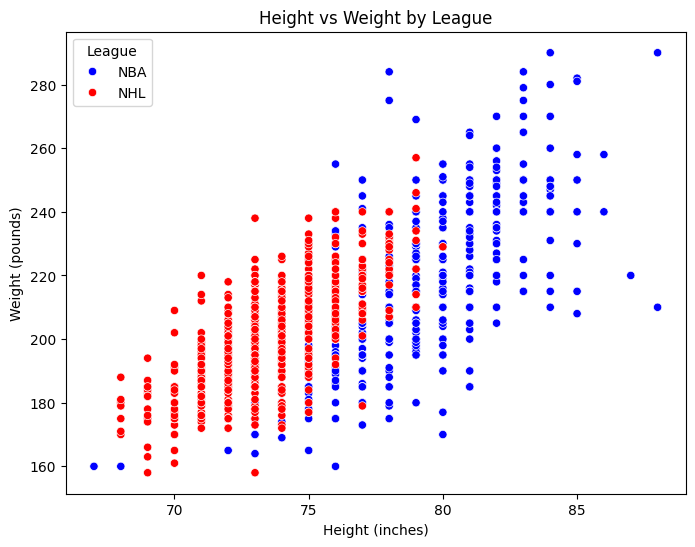

In [12]:
#Visualization of Height vs Weight

import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: height vs weight, colored by league
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=combined_df,
    x="height_in_inches",
    y="weight_in_pounds",
    hue="league",       # color by league
    palette={"NBA":"blue", "NHL":"red"}
)

plt.title("Height vs Weight by League")
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")
plt.legend(title="League")
plt.show()


In [ ]:
import ml
import numpy as np



rows = combined_df[["height_in_inches", "weight_in_pounds", "league"]].values.tolist()


train_rows, test_rows = ml.train_test_split(rows, train_ratio=0.7, seed=42)

# Convert to NumPy arrays
train_rows = np.array(train_rows)
test_rows  = np.array(test_rows)

# Separate into X (height, weight) and y (league)
X_train = train_rows[:, :2].astype(np.float32)   # first two columns
y_train = train_rows[:, 2]    # league column

X_test  = test_rows[:, :2].astype(np.float32)
y_test  = test_rows[:, 2]


knn = ml.KNN(X_train, y_train)

print(knn.error(X_test, y_test))











0.17391304347826086


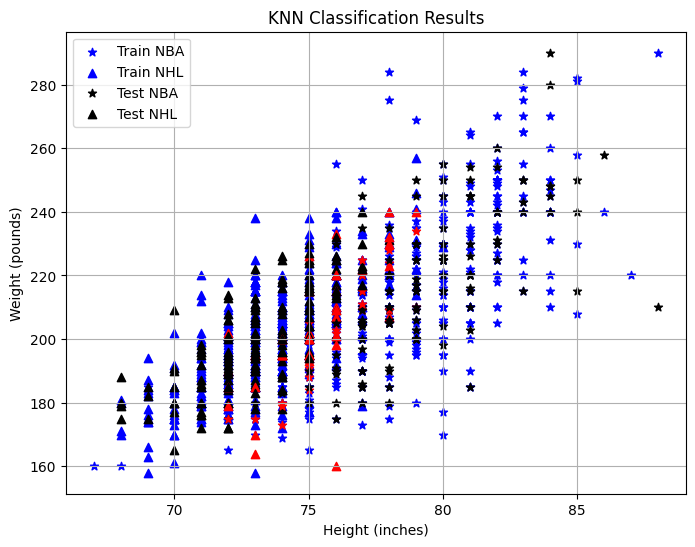

In [16]:
shapes = {"NBA": "*", "NHL": "^"}

plt.figure(figsize=(8,6))

# --- Plot training data ---
for x, label in zip(X_train, y_train):
    marker = shapes[label]
    plt.scatter(x[0], x[1], marker=marker, color="blue", label=f"Train {label}")

# --- Plot test data ---
for x, true_label in zip(X_test, y_test):
    pred_label = knn.predict(x)   # predict one sample at a time
    marker = shapes[pred_label]   # shape based on prediction
    color = "black" if pred_label == true_label else "red"
    plt.scatter(x[0], x[1], marker=marker, color=color, label=f"Test {pred_label}")

# --- Clean up legend ---
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())

plt.title("KNN Classification Results")
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")
plt.grid(True)
plt.show()
